In [5]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units
import matplotlib.patches as patches
from scipy import stats
from endgame import hist2d

from shared.paths import load_paths
paths = load_paths()

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [4]:
cd ..

/home/users/cornkle/pythonWorkspace/proj_CEH


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# VPD helper functions
# ------------------------------------------------------------

def calc_vpd_from_t_q(t, q, p_hpa=1000.):
    """
    Calculate vapour pressure deficit from temperature and specific humidity.

    t     : temperature, usually K. If values look like Celsius, code handles it.
    q     : specific humidity, usually kg/kg. If values look like g/kg, code converts.
    p_hpa : pressure in hPa. Use 1000 hPa as near-surface approximation unless you have psfc.

    returns VPD in hPa.
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    # If q looks like g/kg, convert to kg/kg
    q = np.where(q > 0.1, q / 1000., q)

    # If T looks like Celsius, convert to Kelvin
    t_k = np.where(t < 150, t + 273.15, t)
    t_c = t_k - 273.15

    # saturation vapour pressure, hPa
    es = 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))

    # actual vapour pressure from specific humidity, hPa
    eps = 0.622
    e = (q * p_hpa) / (eps + (1 - eps) * q)

    vpd = es - e
    return vpd


def add_vpd_to_abs_and_anom(abs_df, anom_df, suffix='1deg', p_hpa=1000.):
    """
    Adds VPD to both:
    - abs_df: storm-day absolute VPD
    - anom_df: storm-day VPD anomaly relative to that period's own climate

    Uses:
    storm climate T = storm absolute T - storm T anomaly
    storm climate q = storm absolute q - storm q anomaly
    """

    tvar = f't_srfc_{suffix}'
    qvar = f'q_srfc_{suffix}'
    outvar = f'vpd_srfc_{suffix}'

    # storm-day absolute VPD
    vpd_abs = calc_vpd_from_t_q(abs_df[tvar], abs_df[qvar], p_hpa=p_hpa)

    # reconstruct that period's local/day climatology for T and q
    t_clim = abs_df[tvar] - anom_df[tvar]
    q_clim = abs_df[qvar] - anom_df[qvar]

    # climatological VPD
    vpd_clim = calc_vpd_from_t_q(t_clim, q_clim, p_hpa=p_hpa)

    # add to dataframes
    abs_df[outvar] = vpd_abs
    anom_df[outvar] = vpd_abs - vpd_clim

    return abs_df, anom_df

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def calc_ef(lh, sh):
    """
    Evaporative fraction:
        EF = LH / (LH + SH)

    Assumes LH and SH are in the same units, e.g. W m-2.
    """
    lh = np.asarray(lh, dtype=float)
    sh = np.asarray(sh, dtype=float)

    denom = lh + sh
    ef = np.where(np.isclose(denom, 0) | np.isnan(denom), np.nan, lh / denom)
    return ef


def add_ef_to_abs_and_anom(abs_df, anom_df, suffix='1deg'):
    """
    Adds:
    - ef_1deg to abs_df  = EF from storm-day absolute LH/SH
    - ef_1deg to anom_df = EF_abs - EF_clim

    Do this separately for hist and fut.
    """

    lhvar = f'lh_{suffix}'
    shvar = f'sh_{suffix}'
    outvar = f'ef_{suffix}'

    # storm-day absolute EF
    ef_abs = calc_ef(abs_df[lhvar], abs_df[shvar])

    # reconstruct each period's climatological LH/SH
    lh_clim = abs_df[lhvar] - anom_df[lhvar]
    sh_clim = abs_df[shvar] - anom_df[shvar]

    # climatological EF
    ef_clim = calc_ef(lh_clim, sh_clim)

    # add derived absolute and derived anomaly
    abs_df[outvar] = ef_abs*100
    anom_df[outvar] = (ef_abs - ef_clim)*100

    return abs_df, anom_df

In [8]:
import numpy as np

def calc_thetae_from_t_q(t, q, p_hpa=925.):
    """
    Calculate equivalent potential temperature from temperature and specific humidity.

    t     : temperature, K or degC
    q     : specific humidity, kg/kg or g/kg
    p_hpa : pressure in hPa

    returns theta-e in K
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    # q: g/kg -> kg/kg if needed
    q = np.where(q > 0.1, q / 1000., q)

    # T: Celsius -> Kelvin if needed
    t_k = np.where(t < 150, t + 273.15, t)

    # avoid impossible q values
    q = np.where((q <= 0) | (q >= 1), np.nan, q)

    # mixing ratio, kg/kg
    r = q / (1. - q)

    # vapour pressure, hPa
    eps = 0.622
    e = (q * p_hpa) / (eps + (1. - eps) * q)
    e = np.where(e <= 0, np.nan, e)

    # dewpoint from vapour pressure, K
    ln_ratio = np.log(e / 6.112)
    td_c = (243.5 * ln_ratio) / (17.67 - ln_ratio)
    td_k = td_c + 273.15

    # LCL temperature, K; Bolton-style approximation
    tlcl = 1. / (1. / (td_k - 56.) + np.log(t_k / td_k) / 800.) + 56.

    # potential temperature
    rd_cp = 0.2854
    theta = t_k * (1000. / p_hpa) ** rd_cp

    # equivalent potential temperature
    thetae = theta * np.exp((3376. / tlcl - 2.54) * r * (1. + 0.81 * r))

    return thetae

In [9]:
def add_thetae_to_abs_and_anom(abs_df, anom_df, suffix='1deg', p_hpa=925.):
    """
    Adds theta-e to storm-day absolute and anomaly dataframes.

    abs_df  : lhist or lfut
    anom_df : lahist or lafut

    Adds:
        thetae_calc_1deg to abs_df
        thetae_calc_1deg to anom_df

    thetae anomaly is calculated as:
        thetae_abs - thetae_clim
    """

    tvar = f't_srfc_{suffix}'
    qvar = f'q_srfc_{suffix}'
    outvar = f'thetae_{suffix}'

    thetae_abs = calc_thetae_from_t_q(abs_df[tvar], abs_df[qvar], p_hpa=p_hpa)

    t_clim = abs_df[tvar] - anom_df[tvar]
    q_clim = abs_df[qvar] - anom_df[qvar]

    thetae_clim = calc_thetae_from_t_q(t_clim, q_clim, p_hpa=p_hpa)

    abs_df[outvar] = thetae_abs
    anom_df[outvar] = thetae_abs - thetae_clim

    return abs_df, anom_df

In [10]:
import numpy as np

def saturation_vapour_pressure_hpa(t_k):
    """
    Saturation vapour pressure over liquid water, hPa.
    Input T in K.
    """
    t_c = t_k - 273.15
    return 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))


def calc_thetae_from_t_q(t, q, p_hpa=925.):
    """
    Equivalent potential temperature from T and specific humidity.

    t     : K or degC
    q     : kg/kg or g/kg
    p_hpa : hPa

    returns theta-e in K
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    q = np.where(q > 0.1, q / 1000., q)       # g/kg -> kg/kg if needed
    t_k = np.where(t < 150, t + 273.15, t)   # degC -> K if needed

    q = np.where((q <= 0) | (q >= 1), np.nan, q)

    r = q / (1. - q)

    eps = 0.622
    e = (q * p_hpa) / (eps + (1. - eps) * q)
    e = np.where(e <= 0, np.nan, e)

    ln_ratio = np.log(e / 6.112)
    td_c = (243.5 * ln_ratio) / (17.67 - ln_ratio)
    td_k = td_c + 273.15

    tlcl = 1. / (1. / (td_k - 56.) + np.log(t_k / td_k) / 800.) + 56.

    theta = t_k * (1000. / p_hpa) ** 0.2854
    thetae = theta * np.exp((3376. / tlcl - 2.54) * r * (1. + 0.81 * r))

    return thetae


def calc_thetaes_from_t(t, p_hpa=650.):
    """
    Saturated equivalent potential temperature from T and pressure.

    t     : K or degC
    p_hpa : hPa

    returns saturated theta-e in K
    """

    t = np.asarray(t, dtype=float)
    t_k = np.where(t < 150, t + 273.15, t)

    eps = 0.622

    es = saturation_vapour_pressure_hpa(t_k)
    es = np.where(es >= 0.99 * p_hpa, np.nan, es)

    rs = eps * es / (p_hpa - es)

    # saturated parcel: dewpoint = temperature, LCL approximately T
    tlcl = t_k

    theta = t_k * (1000. / p_hpa) ** 0.2854
    thetaes = theta * np.exp((3376. / tlcl - 2.54) * rs * (1. + 0.81 * rs))

    return thetaes

In [11]:
def add_cape_proxy_to_abs_and_anom(abs_df, anom_df, suffix='1deg',
                                   p_srfc_hpa=925., p_mid_hpa=650.):
    """
    Adds table-based two-level CAPE proxy:

        cape_proxy_calc = thetae_srfc - thetaes_mid

    to both absolute and anomaly dataframes.

    The anomaly is calculated as:

        cape_proxy_abs - cape_proxy_clim

    not from anomaly T/q directly.
    """

    t_s_var = f't_srfc_{suffix}'
    q_s_var = f'q_srfc_{suffix}'
    t_m_var = f't_mid_{suffix}'

    thetae_var  = f'thetae_calc_{suffix}'
    thetaes_var = f'thetaes_mid_calc_{suffix}'
    cape_var    = f'cape_proxy_calc_{suffix}'

    # storm-day absolute values
    thetae_s_abs = calc_thetae_from_t_q(abs_df[t_s_var], abs_df[q_s_var],
                                        p_hpa=p_srfc_hpa)

    thetaes_m_abs = calc_thetaes_from_t(abs_df[t_m_var],
                                        p_hpa=p_mid_hpa)

    cape_abs = thetae_s_abs - thetaes_m_abs

    # reconstruct period climatology
    t_s_clim = abs_df[t_s_var] - anom_df[t_s_var]
    q_s_clim = abs_df[q_s_var] - anom_df[q_s_var]
    t_m_clim = abs_df[t_m_var] - anom_df[t_m_var]

    thetae_s_clim = calc_thetae_from_t_q(t_s_clim, q_s_clim,
                                         p_hpa=p_srfc_hpa)

    thetaes_m_clim = calc_thetaes_from_t(t_m_clim,
                                         p_hpa=p_mid_hpa)

    cape_clim = thetae_s_clim - thetaes_m_clim

    # add to dataframes
    abs_df[thetae_var] = thetae_s_abs
    abs_df[thetaes_var] = thetaes_m_abs
    abs_df[cape_var] = cape_abs

    anom_df[thetae_var] = thetae_s_abs - thetae_s_clim
    anom_df[thetaes_var] = thetaes_m_abs - thetaes_m_clim
    anom_df[cape_var] = cape_abs - cape_clim

    return abs_df, anom_df

In [12]:
lhist_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/hist_mean_table_JASMIN_3hmeansVersion_rainMask_fullBox_ICAPE.csv', index_col=0, low_memory=False).T
lfut_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/fut_mean_table_JASMIN_3hmeansVersion_rainMask_fullBox_ICAPE.csv', index_col=0, low_memory=False).T

In [14]:
lahist_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/hist_anom_table_JASMIN_3hmeansVersion_rainMask_fullBox.csv', index_col=0, low_memory=False).T
lafut_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/fut_anom_table_JASMIN_3hmeansVersion_rainMask_fullBox.csv', index_col=0, low_memory=False).T

In [15]:
for dat in [lahist_orig, lafut_orig, lhist_orig, lfut_orig]:
    for var in dat.keys():
        try:
            dat[var] = dat[var].astype(float)
        except:
            pass

In [16]:
print(len(lahist_orig))
print(len(lhist_orig))

24572
24282


In [17]:
keys = ["pmax", "area", "area_1mm"]
 
common = pd.merge(lahist_orig[keys].drop_duplicates(),lhist_orig[keys].drop_duplicates(),on=keys,how="inner")
lahist_orig = lahist_orig.merge(common, on=keys, how="inner")
lhist_orig = lhist_orig.merge(common, on=keys, how="inner")
 
common = pd.merge(lafut_orig[keys].drop_duplicates(),lfut_orig[keys].drop_duplicates(),on=keys,how="inner")
lafut_orig = lafut_orig.merge(common, on=keys, how="inner")
lfut_orig = lfut_orig.merge(common, on=keys, how="inner")

In [18]:
lahist, lafut, lhist, lfut= [df.copy() for df in (lahist_orig, lafut_orig, lhist_orig, lfut_orig)]

In [19]:
len(lahist)

20014

In [20]:
len(lhist)

20014

In [21]:
np.unique(lahist['month'])

array([7., 8., 9.])

In [22]:
np.unique(lhist['hour'])

array([17., 18., 19.])

In [23]:
lahist['area_1mm'].min()*4.4**2

19.360000000000003

In [24]:
lahist['pmax'].min()

0.4134321472886568

In [25]:
lahist['shear_fullBox'].max()

13.874670028686523

In [118]:
dtag = '2deg'

In [119]:
lhist, lahist = add_vpd_to_abs_and_anom(lhist, lahist, suffix=dtag, p_hpa=925.)
lfut,  lafut  = add_vpd_to_abs_and_anom(lfut,  lafut,  suffix=dtag, p_hpa=925.)

In [120]:
lhist, lahist = add_ef_to_abs_and_anom(lhist, lahist, suffix=dtag)
lfut,  lafut  = add_ef_to_abs_and_anom(lfut,  lafut,  suffix=dtag)

In [121]:
lhist, lahist = add_thetae_to_abs_and_anom(lhist, lahist, suffix=dtag, p_hpa=925.)
lfut,  lafut  = add_thetae_to_abs_and_anom(lfut,  lafut,  suffix=dtag, p_hpa=925.)

In [122]:
lhist, lahist = add_cape_proxy_to_abs_and_anom(lhist, lahist, suffix=dtag, p_srfc_hpa=925., p_mid_hpa=650.)

lfut, lafut = add_cape_proxy_to_abs_and_anom(lfut, lafut, suffix=dtag, p_srfc_hpa=925., p_mid_hpa=650.)

In [123]:
print(len(lhist),len(lahist))

19894 19894


In [124]:
print(list(lafut.keys()))

['tcwv_0.25deg', 'tcwv_1deg', 'tcwv_2deg', 'tcwv_fullBox', 'sh_0.25deg', 'sh_1deg', 'sh_2deg', 'sh_fullBox', 'lh_0.25deg', 'lh_1deg', 'lh_2deg', 'lh_fullBox', 't2_0.25deg', 't2_1deg', 't2_2deg', 't2_fullBox', 'q2_0.25deg', 'q2_1deg', 'q2_2deg', 'q2_fullBox', 'shear_0.25deg', 'shear_1deg', 'shear_2deg', 'shear_fullBox', 'u_mid_0.25deg', 'u_mid_1deg', 'u_mid_2deg', 'u_mid_fullBox', 'u_srfc_0.25deg', 'u_srfc_1deg', 'u_srfc_2deg', 'u_srfc_fullBox', 'v_mid_0.25deg', 'v_mid_1deg', 'v_mid_2deg', 'v_mid_fullBox', 'v_srfc_0.25deg', 'v_srfc_1deg', 'v_srfc_2deg', 'v_srfc_fullBox', 'q_mid_0.25deg', 'q_mid_1deg', 'q_mid_2deg', 'q_mid_fullBox', 't_mid_0.25deg', 't_mid_1deg', 't_mid_2deg', 't_mid_fullBox', 't_srfc_0.25deg', 't_srfc_1deg', 't_srfc_2deg', 't_srfc_fullBox', 'q_srfc_0.25deg', 'q_srfc_1deg', 'q_srfc_2deg', 'q_srfc_fullBox', 'geoH_srfc_0.25deg', 'geoH_srfc_1deg', 'geoH_srfc_2deg', 'geoH_srfc_fullBox', 'lsRain_noon_0.25deg', 'lsRain_noon_1deg', 'lsRain_noon_2deg', 'lsRain_noon_fullBox', 'lw

In [125]:
lahist = lahist[(lhist['pmax']>=1) ]
lhist = lhist[(lhist['pmax']>=1) ]

lafut = lafut[(lfut['pmax']>=1) ]
lfut = lfut[(lfut['pmax']>=1) ]

In [126]:
print(len(lhist),len(lahist))

19894 19894


-3.069373148619687 1.2701124875938048 -4.469566451840368 0.1544570948576085
4748 4877 3322 3515
ef_2deg 71.73405954849916 53.3696897194297 68.51483256340842 43.09861666338599
ICAPEfull_2deg 1432622.2617834941 1684832.262220492 2393620.179456798 2711710.4244436678
div_2deg 0.4276407169328341 0.23259975820347412 0.1502438310969545 -0.3786102728219717
v_mid_2deg -0.43073911855589303 -2.1538928052998547 -0.7903476318305538 -2.3926095785360886
shear_2deg -15.857823476262398 -17.085166815929988 -16.561428854858168 -18.0434394777764


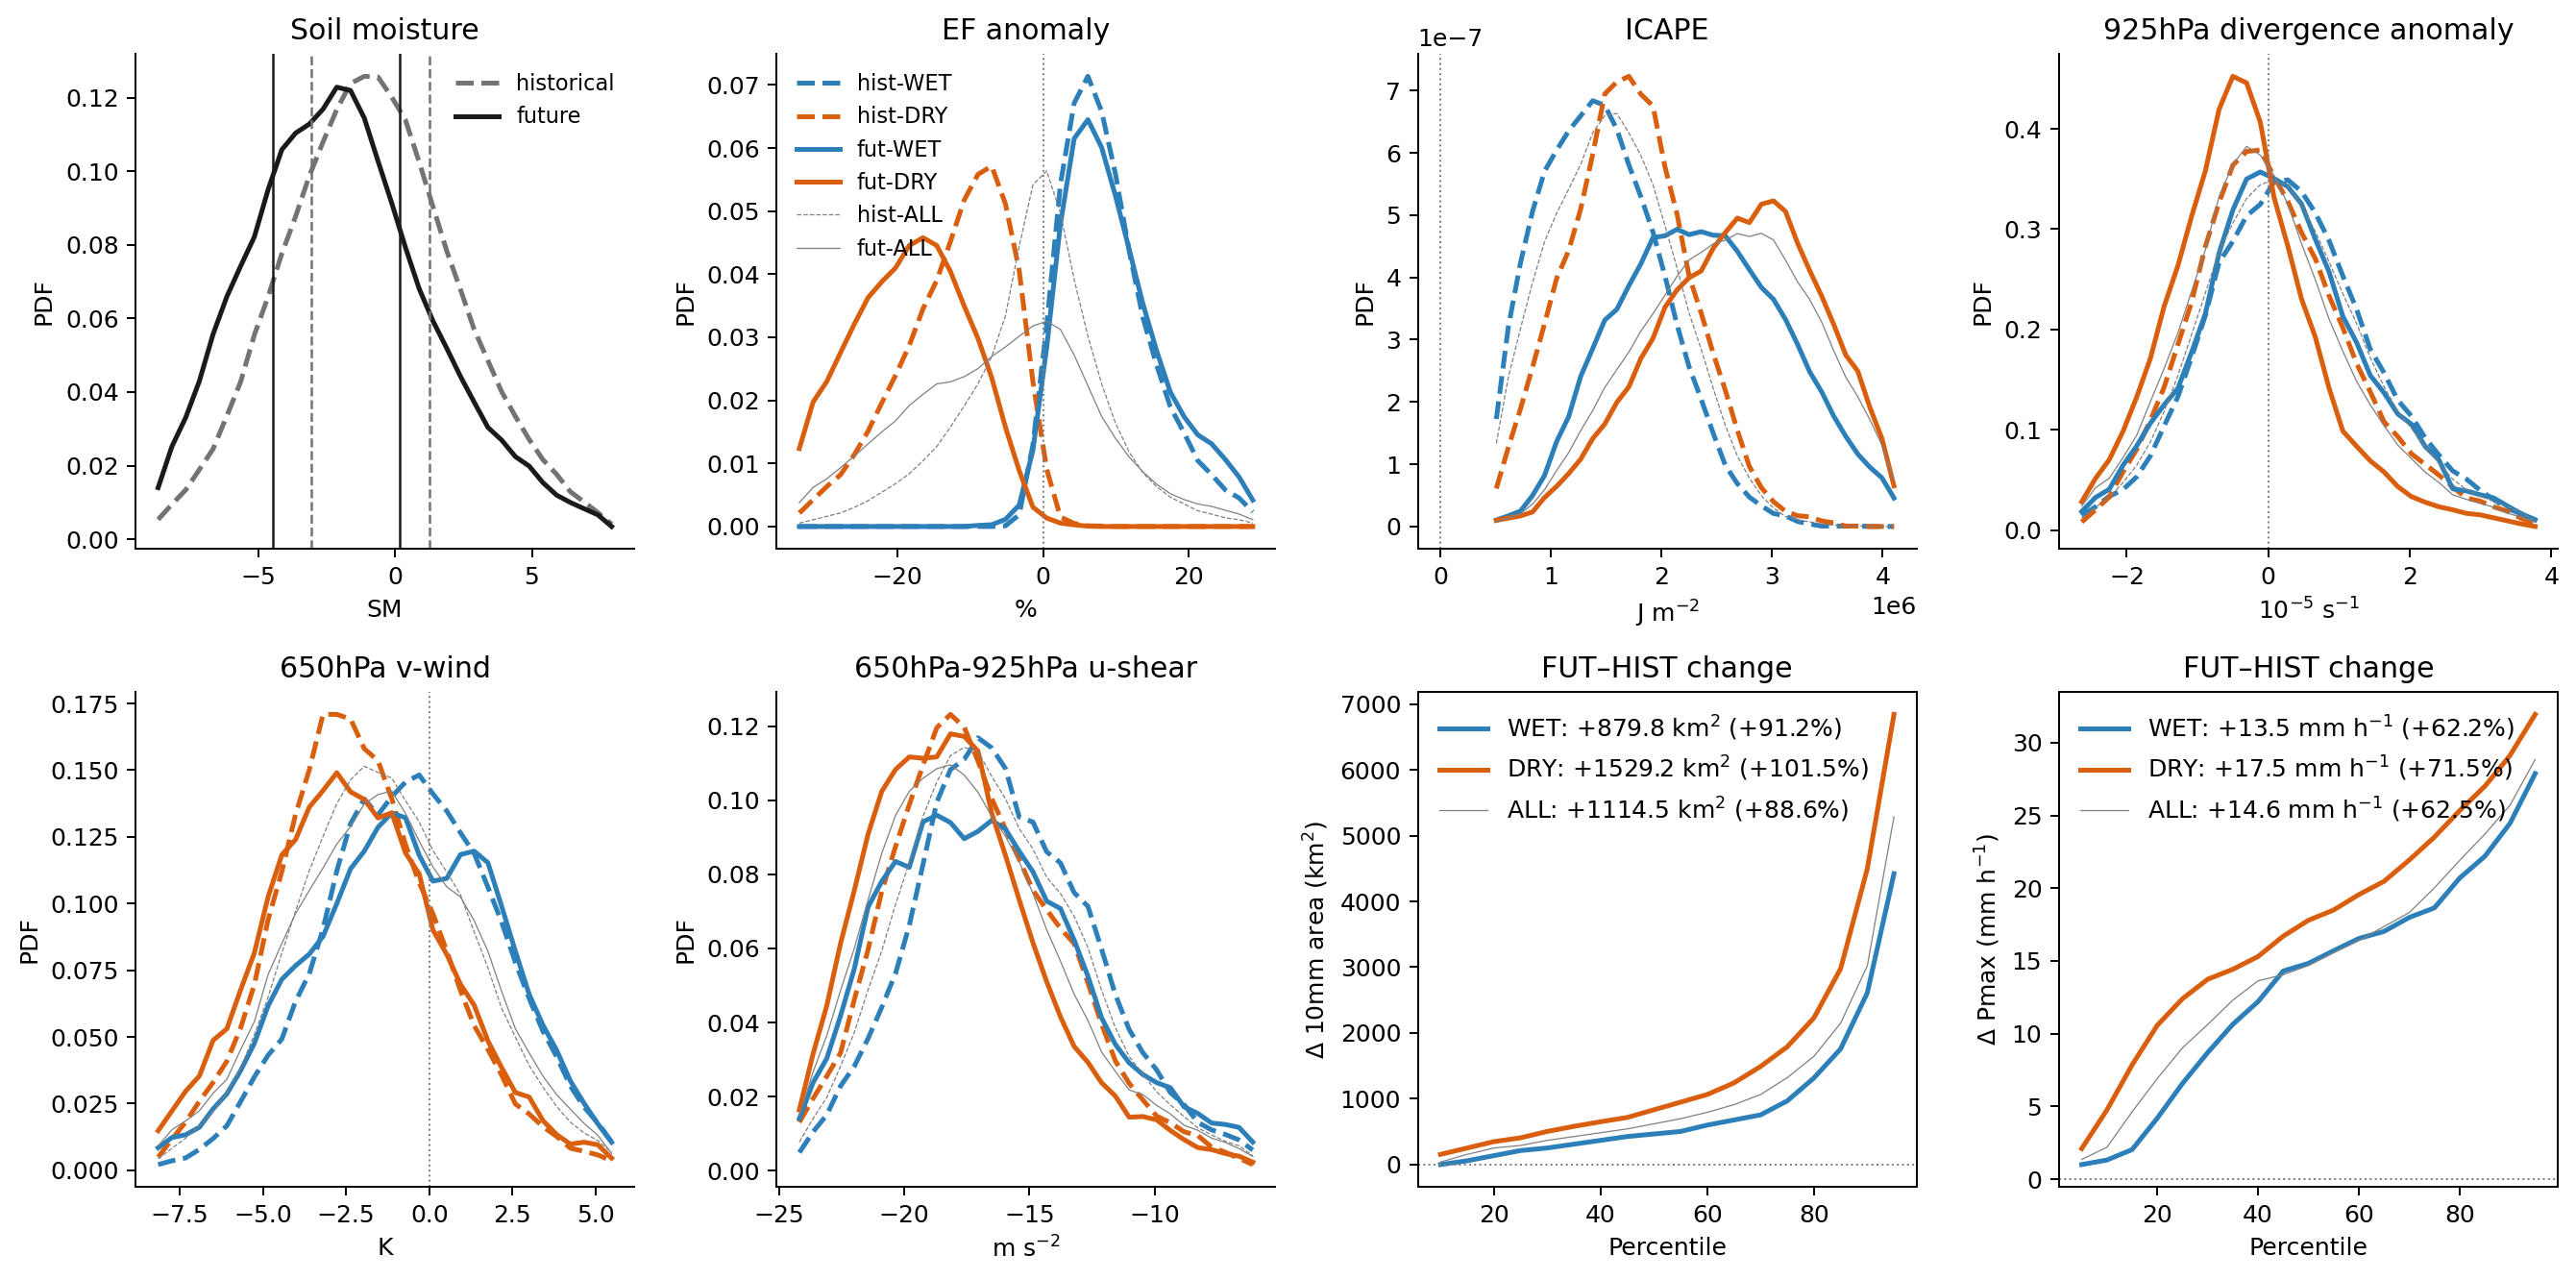

In [172]:
# ------------------------------------------------------------
# SM split (same logic as your current code)
# ------------------------------------------------------------
v_thresh_up = 50# m/s
v_thresh_down = -50
area_thresh = 500000

hist_north = (lhist['v_mid_fullBox'] < v_thresh_up) & (lhist['v_mid_fullBox'] > v_thresh_down)
fut_north  = (lfut['v_mid_fullBox'] < v_thresh_up) & (lfut['v_mid_fullBox'] > v_thresh_down)

hist_area = (lhist['area']*4.4**2<area_thresh)
fut_area  = (lfut['area']*4.4**2<area_thresh)

histp25, histp75 = np.nanpercentile(lahist['SM_2deg'], [25, 75])
futp25, futp75   = np.nanpercentile(lafut['SM_2deg'], [25, 75])

histposlow  = (lahist['SM_'+dtag] > histp75) & hist_north & hist_area  # WET
histposhigh = (lahist['SM_'+dtag] < histp25) & hist_north & hist_area   # DRY
histall = hist_area

futposlow   = (lafut['SM_'+dtag] > futp75) & fut_north & fut_area     # WET
futposhigh  = (lafut['SM_'+dtag] < futp25) & fut_north & fut_area     # DRY
futall =  fut_area


# histposlow  =  hist_north & hist_area  # WET
# histposhigh = (lahist['SM_'+dtag] < histp25) & hist_north & hist_area   # DRY

# futposlow   =  fut_north & fut_area     # WET
# futposhigh  = (lafut['SM_'+dtag] < futp25) & fut_north & fut_area     # DRY

print(histp25, histp75, futp25, futp75)
print(np.sum(histposlow), np.sum(histposhigh), np.sum(futposlow), np.sum(futposhigh))


# ------------------------------------------------------------
# Colours / styles
# ------------------------------------------------------------
wet_col  = '#2C7FB8'
dry_col  = '#D95F0E'
hist_col = '0.45'
fut_col  = '0.10'


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _clean(x, scale=1):
    x = np.asarray(x, dtype=float) * scale
    return x[np.isfinite(x)]

def _smooth(y, n=3):
    if n <= 1:
        return y
    kernel = np.ones(n) / n
    return np.convolve(y, kernel, mode='same')

def _make_bins(arrs, nbins=36, qrange=(1, 99)):
    zz = np.concatenate([a for a in arrs if len(a) > 0])
    lo, hi = np.nanpercentile(zz, qrange)
    return np.linspace(lo, hi, nbins + 1)

def _pdf(vals, bins, smooth=3):
    h, edges = np.histogram(vals, bins=bins, density=True)
    mids = 0.5 * (edges[1:] + edges[:-1])
    return mids, _smooth(h, n=smooth)

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out')

def plot_sm_pdf(ax):
    hsm = _clean(lahist['SM_2deg'])
    fsm = _clean(lafut['SM_2deg'])
    bins = _make_bins([hsm, fsm], nbins=34, qrange=(1, 99))

    x, y = _pdf(hsm, bins, smooth=3)
    ax.plot(x, y, color=hist_col, ls='--', lw=2, label='historical')

    x, y = _pdf(fsm, bins, smooth=3)
    ax.plot(x, y, color=fut_col, ls='-', lw=2, label='future')

    ax.axvline(histp25, color=hist_col, ls='--', lw=1)
    ax.axvline(histp75, color=hist_col, ls='--', lw=1)
    ax.axvline(futp25,  color=fut_col,  ls='-',  lw=1)
    ax.axvline(futp75,  color=fut_col,  ls='-',  lw=1)

    ymax = ax.get_ylim()[1]
    # ax.text(histp25, ymax*0.95, 'H25', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(histp75, ymax*0.95, 'H75', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(futp25,  ymax*0.85, 'F25', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)
    # ax.text(futp75,  ymax*0.85, 'F75', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)

    ax.set_title('Soil moisture')
    ax.set_xlabel('SM')
    ax.set_ylabel('PDF')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)

def plot_group_pdf(ax, var, title, xlabel, scale=1, zero_line=False, nbins=34, qrange=(1, 99), smooth=3):

    if var not in ['tcwv_2deg', 'v_mid_2deg', 'ICAPEfull_2deg', 'shear_2deg']:
        hwet = _clean(lahist[var][histposlow], scale=scale)
        hdry = _clean(lahist[var][histposhigh], scale=scale)
        fwet = _clean(lafut[var][futposlow], scale=scale)
        fdry = _clean(lafut[var][futposhigh], scale=scale)
        hall = _clean(lahist[var][histall], scale=scale)
        fall = _clean(lafut[var][futall], scale=scale)
    else:
        hwet = _clean(lhist[var][histposlow], scale=scale)
        hdry = _clean(lhist[var][histposhigh], scale=scale)
        fwet = _clean(lfut[var][futposlow], scale=scale)
        fdry = _clean(lfut[var][futposhigh], scale=scale)
        hall = _clean(lhist[var][histall], scale=scale)
        fall = _clean(lfut[var][futall], scale=scale)

    hwet_mean = _clean(lhist[var][histposlow], scale=scale)
    hdry_mean = _clean(lhist[var][histposhigh], scale=scale)
    fwet_mean = _clean(lfut[var][futposlow], scale=scale)
    fdry_mean = _clean(lfut[var][futposhigh], scale=scale)



    print(var, np.mean(hwet_mean), np.mean(hdry_mean), np.mean(fwet_mean), np.mean(fdry_mean))

    bins = _make_bins([hwet, hdry, fwet, fdry, hall, fall], nbins=nbins, qrange=qrange)

    for vals, col, ls, lab, lw in [
        (hwet, wet_col, '--', 'hist-WET', 2),
        (hdry, dry_col, '--', 'hist-DRY', 2),
        (fwet, wet_col, '-',  'fut-WET', 2),
        (fdry, dry_col, '-',  'fut-DRY', 2),
        (hall, 'grey', '--',  'hist-ALL', 0.5),
        (fall, 'grey', '-',  'fut-ALL', 0.5),
    ]:
        x, y = _pdf(vals, bins, smooth=smooth)
        ax.plot(x, y, color=col, ls=ls, lw=lw, label=lab)

    if zero_line:
        ax.axvline(0, color='0.5', ls=':', lw=0.8)
        
    if 'ef' in var:
        ax.legend(frameon=False, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PDF')
    style_ax(ax)


def _plot_change_panel(ax, var, pp, factor, unit, ylabel):
        groups = [('WET', histposlow, futposlow, '#2C7FB8', 2),
                  ('DRY', histposhigh, futposhigh, '#D95F0E', 2),
                  ('ALL', histall, futall, 'grey', 0.5)]
        
        for label, hmask, fmask, color, lw in groups:
            hist = np.nanpercentile(lahist.loc[hmask, var] * factor, pp)
            fut = np.nanpercentile(lafut.loc[fmask, var] * factor, pp)
            change = fut - hist
            absolute = np.mean(change)
            baseline = np.mean(hist)
            relative = 100 * absolute / baseline if baseline != 0 else np.nan
        
            legend = f'{label}: {absolute:+.1f} {unit} ({relative:+.1f}%)'
            ax.plot(pp, change, color=color, lw=lw, label=legend)
        
        ax.axhline(0, color='0.5', ls=':', lw=0.8)
        ax.set_xlabel('Percentile')
        ax.set_ylabel(ylabel)
        ax.set_title('FUT–HIST change')
        ax.legend(frameon=False)


def plot_area_panel(ax):
        _plot_change_panel(ax, 'area_10mm', np.arange(10, 100, 5), 4.4**2,
                           r'km$^2$', r'$\Delta$ 10mm area (km$^2$)')


def plot_pmax_panel(ax):
        _plot_change_panel(ax, 'pmax', np.arange(5, 100, 5), 1,
                           r'mm h$^{-1}$', r'$\Delta$ Pmax (mm h$^{-1}$)')

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axs = plt.subplots(2,4, figsize=(15, 7.5), dpi=180)
axs = axs.ravel()

# 1) full SM distribution
plot_sm_pdf(axs[0])

# 2-6) associated environmental variables
plot_group_pdf(axs[1], 'ef_'+dtag,   'EF anomaly',         '%', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[2], 'ICAPEfull_'+dtag,   'ICAPE',       'J m$^{-2}$', scale=1, zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[3], 'div_'+dtag,  '925hPa divergence anomaly',     '$10^{-5}$ s$^{-1}$', scale=1e5, zero_line=True, nbins=34, qrange=(1, 99)),
plot_group_pdf(axs[4], 'v_mid_'+dtag,   r'650hPa v-wind',       'K', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[5], 'shear_'+dtag,   '650hPa-925hPa u-shear','m s$^{-2}$',         zero_line=False, nbins=34, qrange=(1, 99))

               

# 7-8) storm characteristics
plot_area_panel(axs[6])
plot_pmax_panel(axs[7])

plt.tight_layout()
# fig.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SMsplit_variable_distributions_clean.png', dpi=200)
plt.show()

<>:197: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:197: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
/tmp/ipykernel_148/2827337203.py:197: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  plot_group_pdf(axs[5], r'thetae_'+dtag,   '$\Theta$-e','K',         zero_line=False, nbins=34, qrange=(1, 99))


-3.069373148619687 1.2701124875938048 -4.469566451840368 0.1544570948576085
1102 1192 668 741
ef_2deg 72.54651907675986 52.30322634963834 70.45563584293303 43.363435004707476
ICAPEfull_2deg 1434597.5032699737 1633207.6883583574 2458377.8584904685 2746754.070291687
div_2deg 0.3784701591642458 0.31840951289198904 0.19563804671688304 -0.23542441067147377
t2_2deg 301.3352452682066 303.77394651329223 306.7566201652213 309.509467286283
thetae_2deg 351.2196369745348 351.4824631915123 374.53334005159985 374.28809302277654
geoH_srfc_2deg 780.5693702693428 779.2444284826176 795.8733012043108 791.9564022138758
shear_2deg -16.22315102980094 -16.726878201686183 -17.023541612231472 -18.108217666957003
v_mid_2deg -1.4455358828907898 -1.3699786955713846 -1.4807219275670709 -1.4055117265050368
tcwv_2deg 45.36544217110619 44.48769230973179 66.59612061463623 65.1680628987091


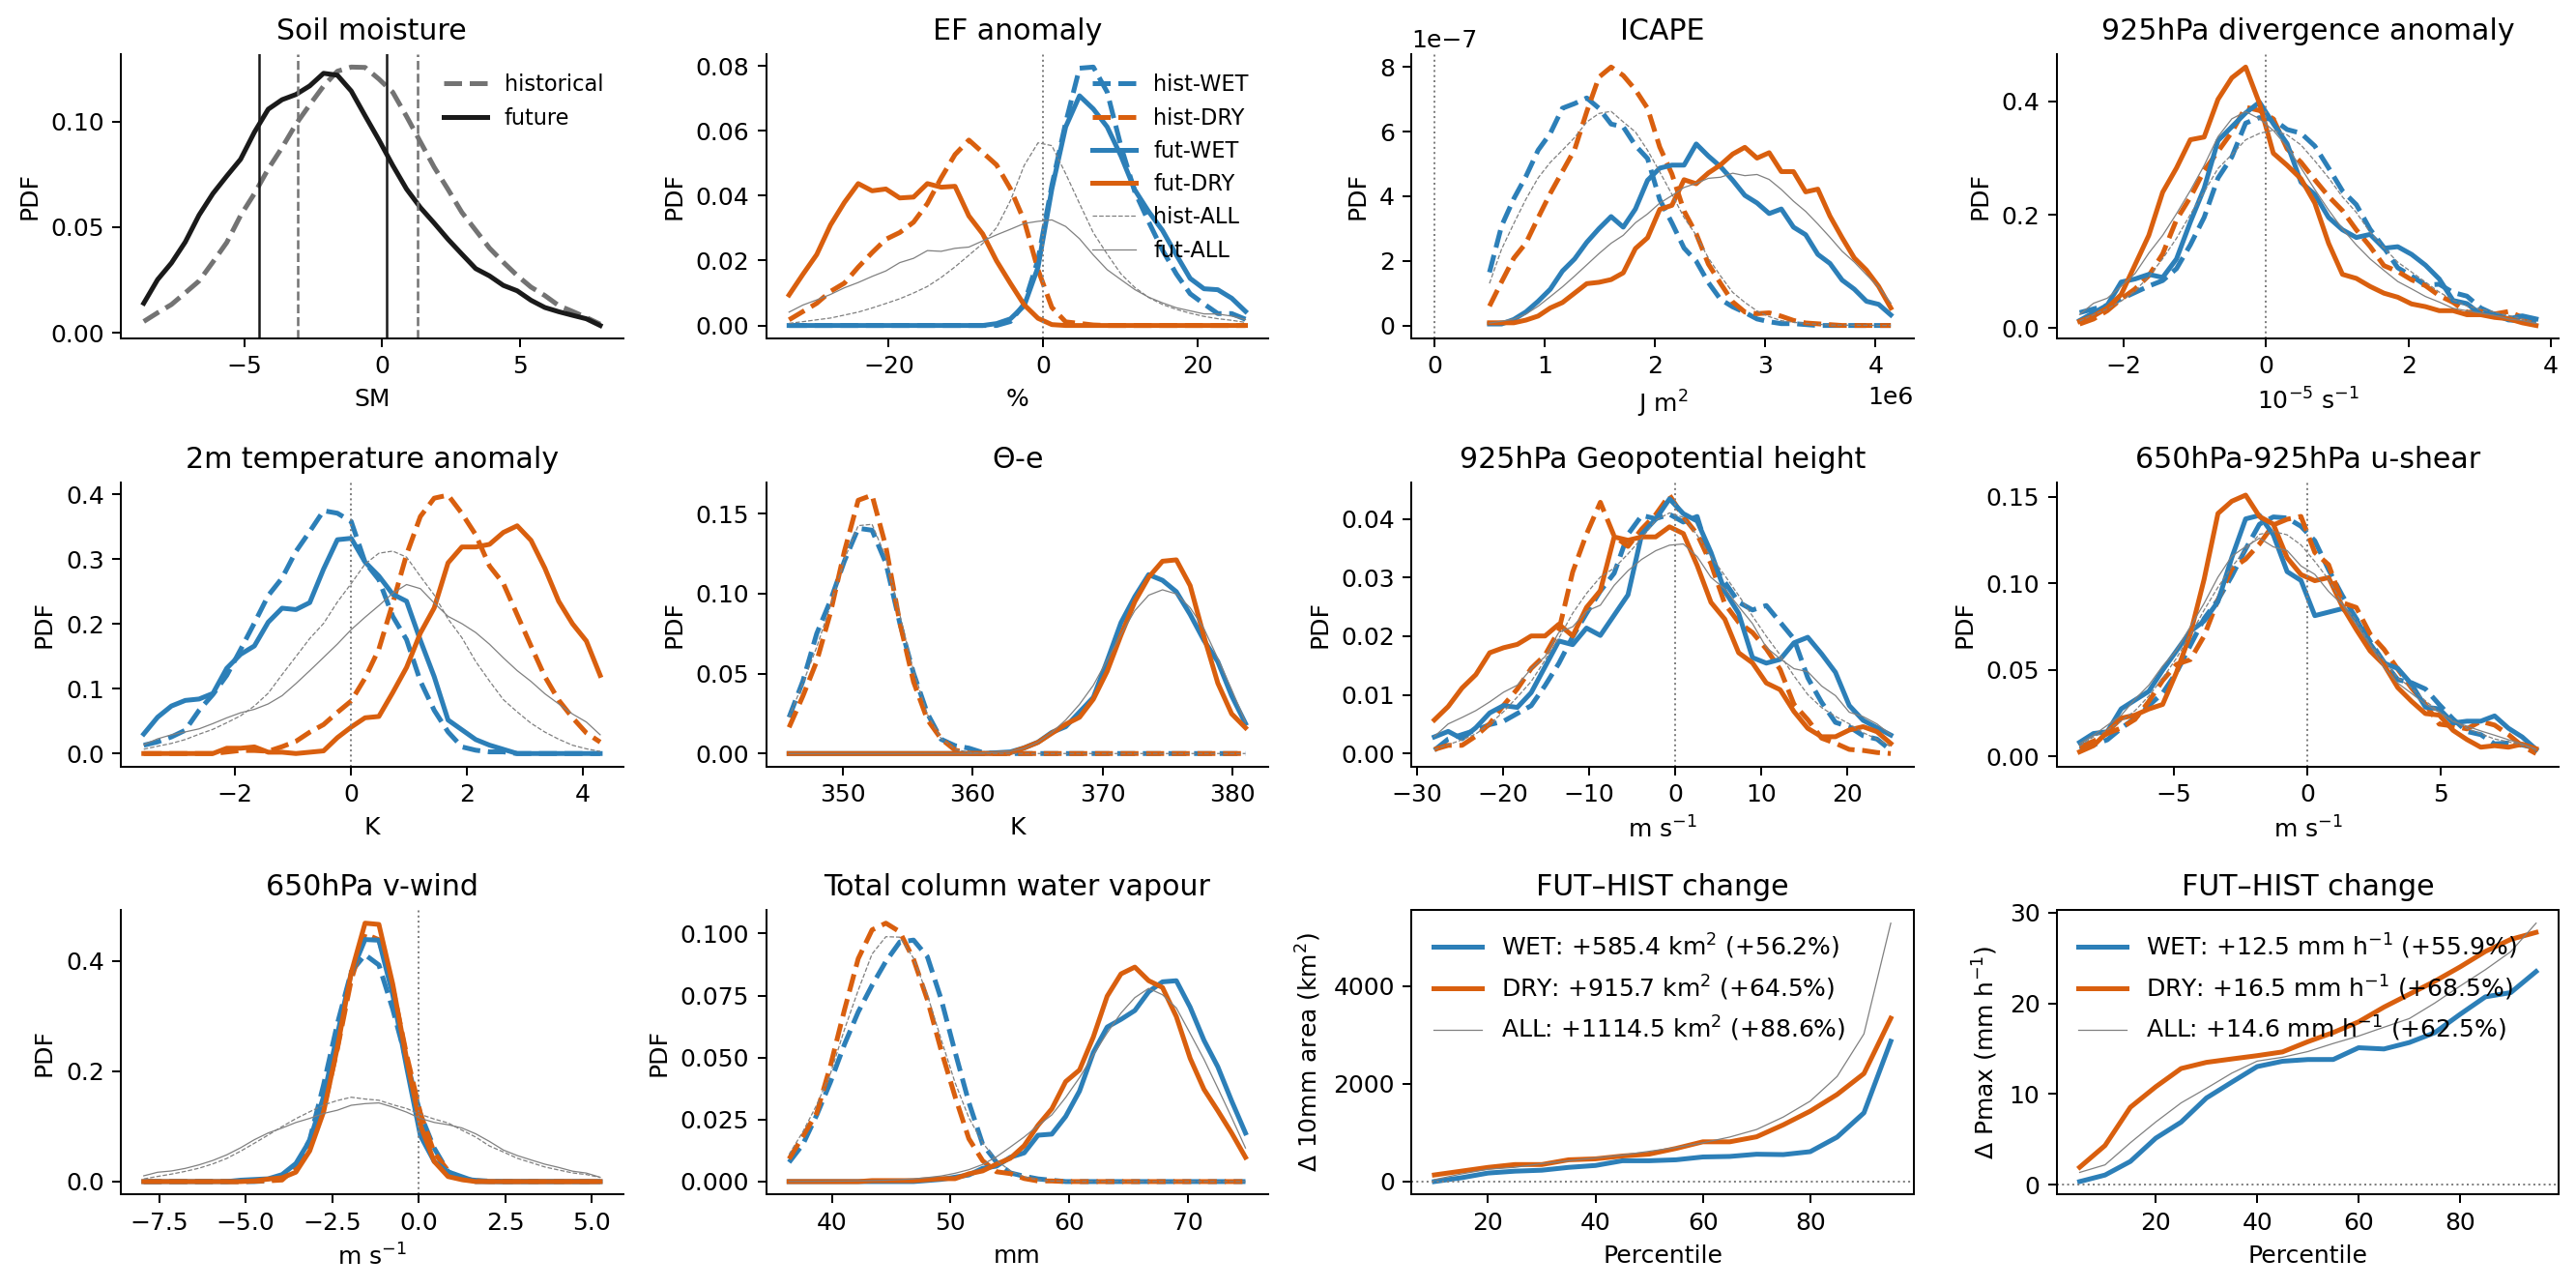

In [129]:
# ------------------------------------------------------------
# SM split (same logic as your current code)
# ------------------------------------------------------------
v_thresh_up = -0.5# m/s
v_thresh_down = -2
area_thresh = 500000

hist_north = (lhist['v_mid_fullBox'] < v_thresh_up) & (lhist['v_mid_fullBox'] > v_thresh_down)
fut_north  = (lfut['v_mid_fullBox'] < v_thresh_up) & (lfut['v_mid_fullBox'] > v_thresh_down)

hist_area = (lhist['area']*4.4**2<area_thresh)
fut_area  = (lfut['area']*4.4**2<area_thresh)

histp25, histp75 = np.nanpercentile(lahist['SM_2deg'], [25, 75])
futp25, futp75   = np.nanpercentile(lafut['SM_2deg'], [25, 75])

histposlow  = (lahist['SM_2deg'] > histp75) & hist_north & hist_area  # WET
histposhigh = (lahist['SM_2deg'] < histp25) & hist_north & hist_area   # DRY
histall = hist_area

futposlow   = (lafut['SM_2deg'] > futp75) & fut_north & fut_area     # WET
futposhigh  = (lafut['SM_2deg'] < futp25) & fut_north & fut_area     # DRY
futall =  fut_area


# histposlow  =  hist_north & hist_area  # WET
# histposhigh = (lahist['SM_'+dtag] < histp25) & hist_north & hist_area   # DRY

# futposlow   =  fut_north & fut_area     # WET
# futposhigh  = (lafut['SM_'+dtag] < futp25) & fut_north & fut_area     # DRY

print(histp25, histp75, futp25, futp75)
print(np.sum(histposlow), np.sum(histposhigh), np.sum(futposlow), np.sum(futposhigh))


# ------------------------------------------------------------
# Colours / styles
# ------------------------------------------------------------
wet_col  = '#2C7FB8'
dry_col  = '#D95F0E'
hist_col = '0.45'
fut_col  = '0.10'


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _clean(x, scale=1):
    x = np.asarray(x, dtype=float) * scale
    return x[np.isfinite(x)]

def _smooth(y, n=3):
    if n <= 1:
        return y
    kernel = np.ones(n) / n
    return np.convolve(y, kernel, mode='same')

def _make_bins(arrs, nbins=36, qrange=(1, 99)):
    zz = np.concatenate([a for a in arrs if len(a) > 0])
    lo, hi = np.nanpercentile(zz, qrange)
    return np.linspace(lo, hi, nbins + 1)

def _pdf(vals, bins, smooth=3):
    h, edges = np.histogram(vals, bins=bins, density=True)
    mids = 0.5 * (edges[1:] + edges[:-1])
    return mids, _smooth(h, n=smooth)

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out')

def plot_sm_pdf(ax):
    hsm = _clean(lahist['SM_2deg'])
    fsm = _clean(lafut['SM_2deg'])
    bins = _make_bins([hsm, fsm], nbins=34, qrange=(1, 99))

    x, y = _pdf(hsm, bins, smooth=3)
    ax.plot(x, y, color=hist_col, ls='--', lw=2, label='historical')

    x, y = _pdf(fsm, bins, smooth=3)
    ax.plot(x, y, color=fut_col, ls='-', lw=2, label='future')

    ax.axvline(histp25, color=hist_col, ls='--', lw=1)
    ax.axvline(histp75, color=hist_col, ls='--', lw=1)
    ax.axvline(futp25,  color=fut_col,  ls='-',  lw=1)
    ax.axvline(futp75,  color=fut_col,  ls='-',  lw=1)

    ymax = ax.get_ylim()[1]
    # ax.text(histp25, ymax*0.95, 'H25', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(histp75, ymax*0.95, 'H75', rotation=90, va='top', ha='right', fontsize=8, color=hist_col)
    # ax.text(futp25,  ymax*0.85, 'F25', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)
    # ax.text(futp75,  ymax*0.85, 'F75', rotation=90, va='top', ha='left',  fontsize=8, color=fut_col)

    ax.set_title('Soil moisture')
    ax.set_xlabel('SM')
    ax.set_ylabel('PDF')
    ax.legend(frameon=False, fontsize=9)
    style_ax(ax)

def plot_group_pdf(ax, var, title, xlabel, scale=1, zero_line=False, nbins=34, qrange=(1, 99), smooth=3):

    if var not in ['tcwv_2deg', 'v_mid_2deg', 'ICAPEfull_2deg', 'thetae_2deg']:
        hwet = _clean(lahist[var][histposlow], scale=scale)
        hdry = _clean(lahist[var][histposhigh], scale=scale)
        fwet = _clean(lafut[var][futposlow], scale=scale)
        fdry = _clean(lafut[var][futposhigh], scale=scale)
        hall = _clean(lahist[var][histall], scale=scale)
        fall = _clean(lafut[var][futall], scale=scale)
    else:
        hwet = _clean(lhist[var][histposlow], scale=scale)
        hdry = _clean(lhist[var][histposhigh], scale=scale)
        fwet = _clean(lfut[var][futposlow], scale=scale)
        fdry = _clean(lfut[var][futposhigh], scale=scale)
        hall = _clean(lhist[var][histall], scale=scale)
        fall = _clean(lfut[var][futall], scale=scale)

    hwet_mean = _clean(lhist[var][histposlow], scale=scale)
    hdry_mean = _clean(lhist[var][histposhigh], scale=scale)
    fwet_mean = _clean(lfut[var][futposlow], scale=scale)
    fdry_mean = _clean(lfut[var][futposhigh], scale=scale)



    print(var, np.mean(hwet_mean), np.mean(hdry_mean), np.mean(fwet_mean), np.mean(fdry_mean))

    bins = _make_bins([hwet, hdry, fwet, fdry, hall, fall], nbins=nbins, qrange=qrange)

    for vals, col, ls, lab, lw in [
        (hwet, wet_col, '--', 'hist-WET', 2),
        (hdry, dry_col, '--', 'hist-DRY', 2),
        (fwet, wet_col, '-',  'fut-WET', 2),
        (fdry, dry_col, '-',  'fut-DRY', 2),
        (hall, 'grey', '--',  'hist-ALL', 0.5),
        (fall, 'grey', '-',  'fut-ALL', 0.5),
    ]:
        x, y = _pdf(vals, bins, smooth=smooth)
        ax.plot(x, y, color=col, ls=ls, lw=lw, label=lab)

    if zero_line:
        ax.axvline(0, color='0.5', ls=':', lw=0.8)
        
    if 'ef' in var:
        ax.legend(frameon=False, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PDF')
    style_ax(ax)


def _plot_change_panel(ax, var, pp, factor, unit, ylabel):
        groups = [('WET', histposlow, futposlow, '#2C7FB8', 2),
                  ('DRY', histposhigh, futposhigh, '#D95F0E', 2),
                  ('ALL', histall, futall, 'grey', 0.5)]
        
        for label, hmask, fmask, color, lw in groups:
            hist = np.nanpercentile(lahist.loc[hmask, var] * factor, pp)
            fut = np.nanpercentile(lafut.loc[fmask, var] * factor, pp)
            change = fut - hist
            absolute = np.mean(change)
            baseline = np.mean(hist)
            relative = 100 * absolute / baseline if baseline != 0 else np.nan
        
            legend = f'{label}: {absolute:+.1f} {unit} ({relative:+.1f}%)'
            ax.plot(pp, change, color=color, lw=lw, label=legend)
        
        ax.axhline(0, color='0.5', ls=':', lw=0.8)
        ax.set_xlabel('Percentile')
        ax.set_ylabel(ylabel)
        ax.set_title('FUT–HIST change')
        ax.legend(frameon=False)


def plot_area_panel(ax):
        _plot_change_panel(ax, 'area_10mm', np.arange(10, 100, 5), 4.4**2,
                           r'km$^2$', r'$\Delta$ 10mm area (km$^2$)')


def plot_pmax_panel(ax):
        _plot_change_panel(ax, 'pmax', np.arange(5, 100, 5), 1,
                           r'mm h$^{-1}$', r'$\Delta$ Pmax (mm h$^{-1}$)')

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axs = plt.subplots(3,4, figsize=(15, 7.5), dpi=180)
axs = axs.ravel()

# 1) full SM distribution
plot_sm_pdf(axs[0])

# 2-6) associated environmental variables
plot_group_pdf(axs[1], 'ef_'+dtag,   'EF anomaly',         '%', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[2], r'ICAPEfull_'+dtag,   'ICAPE',       r'J m$^{2}$', scale=1, zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[3], 'div_'+dtag,  '925hPa divergence anomaly',     r'$10^{-5}$ s$^{-1}$', scale=1e5, zero_line=True, nbins=34, qrange=(1, 99))
plot_group_pdf(axs[4], 't2_'+dtag,   r'2m temperature anomaly',       'K', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[5], r'thetae_'+dtag,   '$\Theta$-e','K',         zero_line=False, nbins=34, qrange=(1, 99))

               

# 7-8) storm characteristics
plot_group_pdf(axs[6], r'geoH_srfc_'+dtag, r'925hPa Geopotential height', r'm s$^{-1}$', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[7], r'shear_'+dtag, r'650hPa-925hPa u-shear', r'm s$^{-1}$', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[8], r'v_mid_'+dtag, r'650hPa v-wind',       r'm s$^{-1}$', zero_line=True,  nbins=34, qrange=(1, 99))
plot_group_pdf(axs[9], 'tcwv_'+dtag,'Total column water vapour','mm',         zero_line=False, nbins=34, qrange=(1, 99))

               

# 7-8) storm characteristics
plot_area_panel(axs[10])
plot_pmax_panel(axs[11])

plt.tight_layout()
# fig.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SMsplit_variable_distributions_clean.png', dpi=200)
plt.show()

SM thresholds: -3.069373148619687 1.2701124875938048 -4.469566451840368 0.1544570948576085
Sample sizes (H-WET, H-DRY, F-WET, F-DRY): 4748 4877 3322 3515
ef_2deg absolute means (H-WET, H-DRY, F-WET, F-DRY): 71.73405954849916 53.3696897194297 68.51483256340842 43.09861666338599
div_2deg absolute means (H-WET, H-DRY, F-WET, F-DRY): 0.4276407169328341 0.23259975820347412 0.1502438310969545 -0.3786102728219717
ICAPEfull_2deg absolute means (H-WET, H-DRY, F-WET, F-DRY): 1432622.2617834941 1684832.262220492 2393620.179456798 2711710.4244436678
tcwv_2deg absolute means (H-WET, H-DRY, F-WET, F-DRY): 45.691622088220385 44.48261092107774 66.70486364531179 65.82109642435718


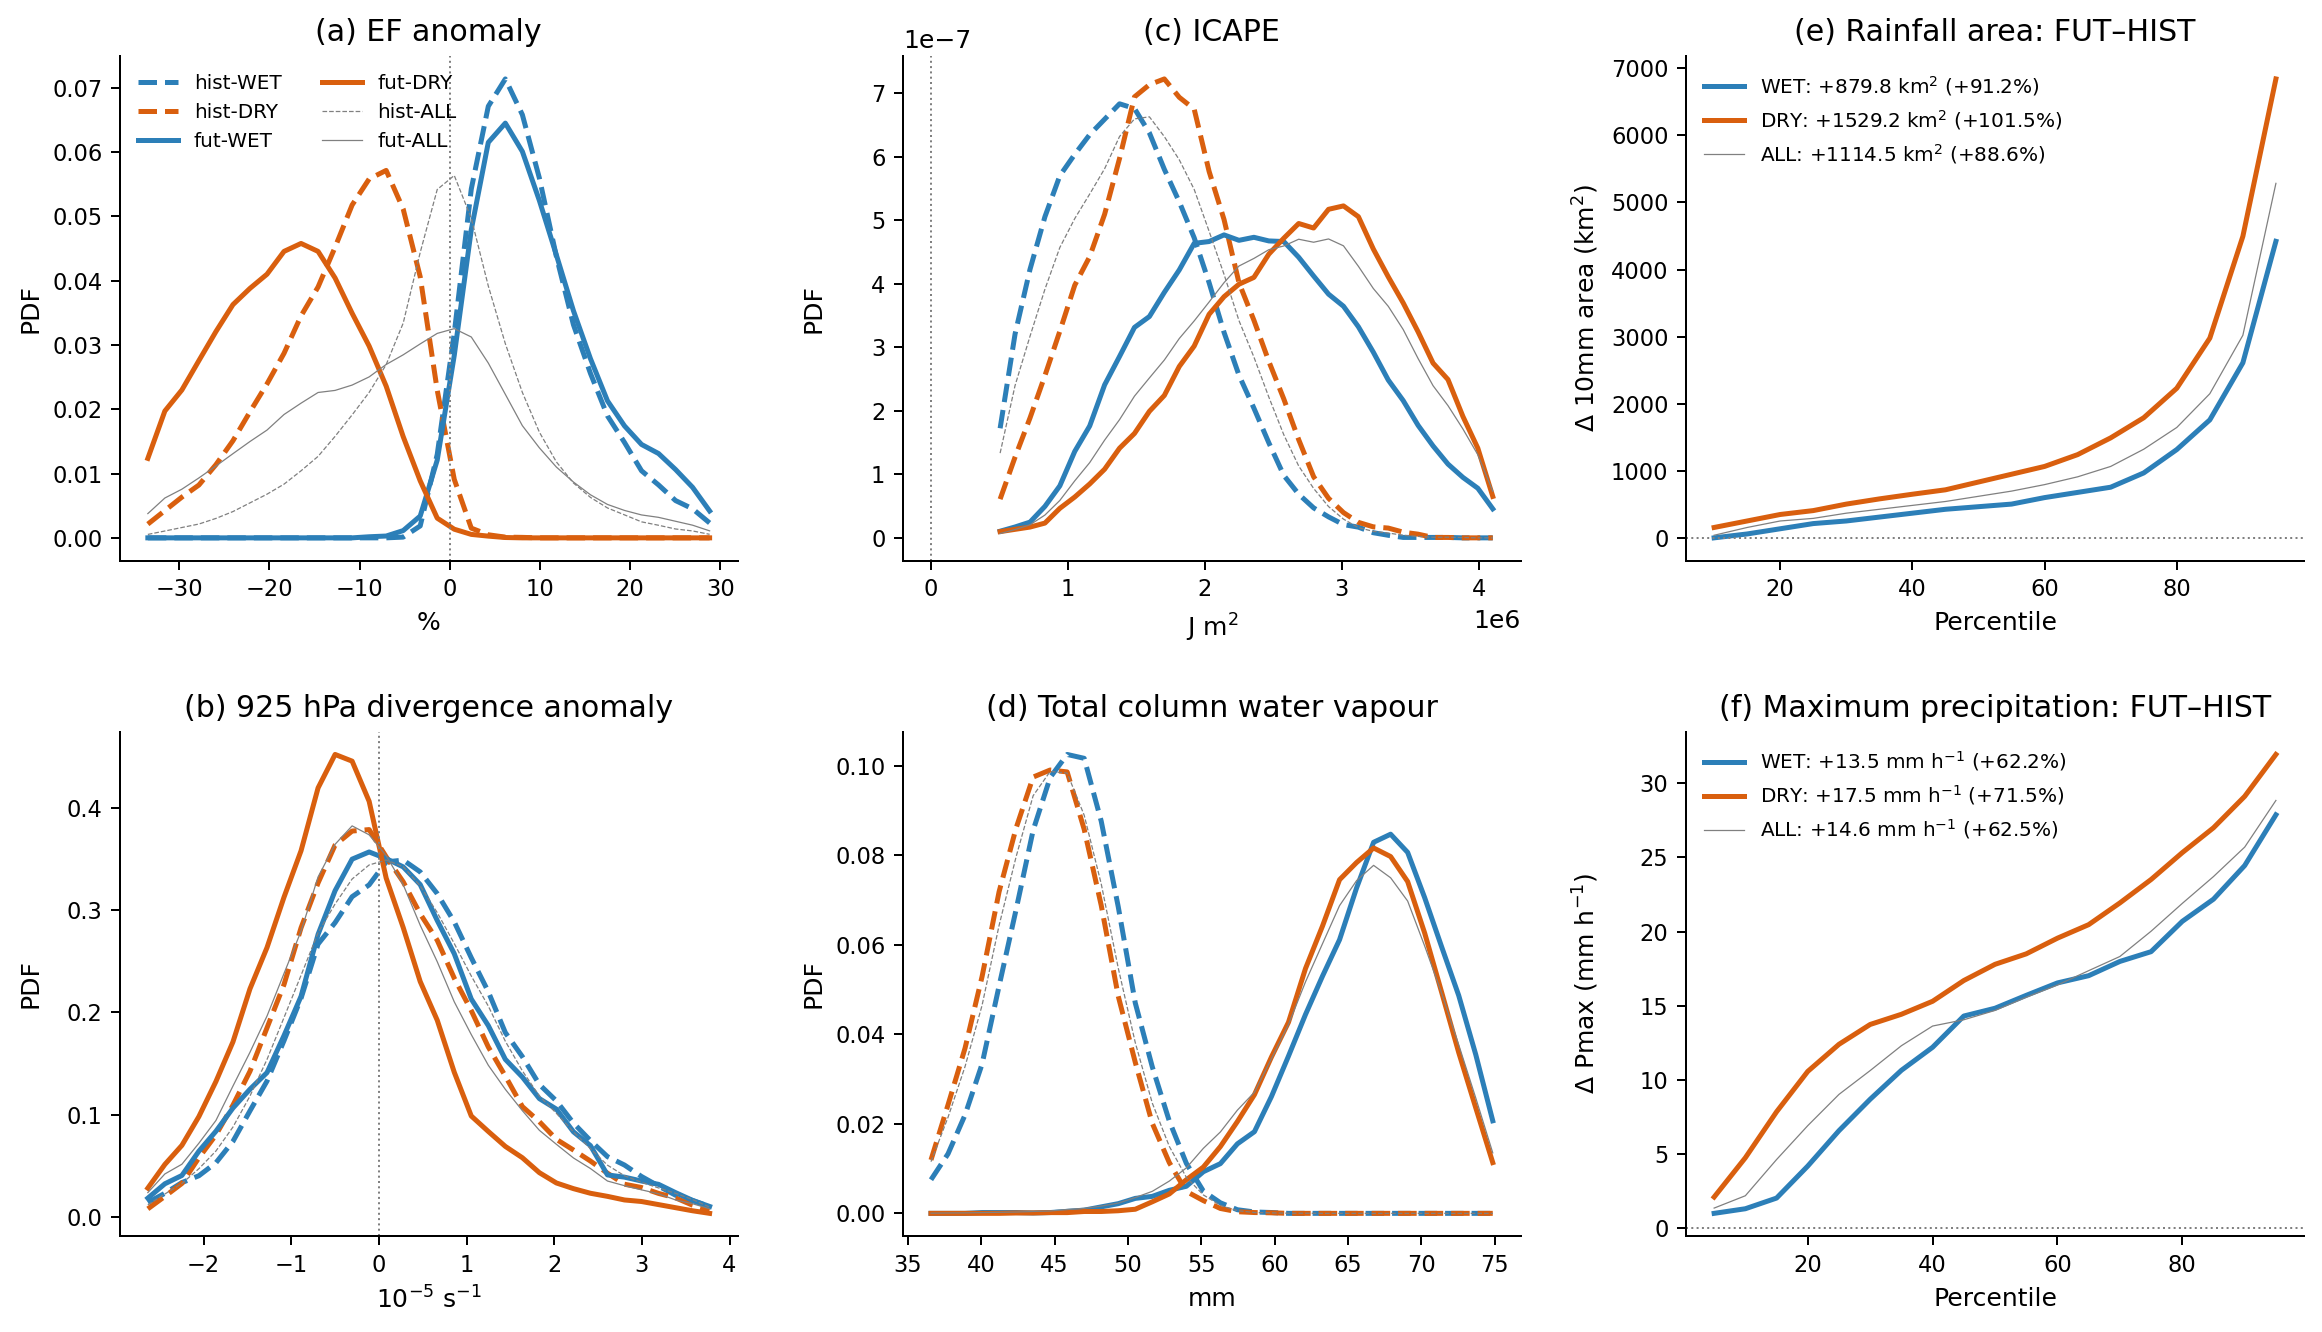

In [167]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SM split and sampling filters
# ------------------------------------------------------------
v_thresh_up, v_thresh_down = 50, -50  # m/s
area_thresh = 500000                  # km²

hist_north = (lhist['v_mid_fullBox'] < v_thresh_up) & (lhist['v_mid_fullBox'] > v_thresh_down)
fut_north = (lfut['v_mid_fullBox'] < v_thresh_up) & (lfut['v_mid_fullBox'] > v_thresh_down)

hist_area = lhist['area'] * 4.4**2 < area_thresh
fut_area = lfut['area'] * 4.4**2 < area_thresh

histp25, histp75 = np.nanpercentile(lahist['SM_2deg'], [25, 75])
futp25, futp75 = np.nanpercentile(lafut['SM_2deg'], [25, 75])

histposlow = (lahist['SM_'+dtag] > histp75) & hist_north & hist_area   # WET
histposhigh = (lahist['SM_'+dtag] < histp25) & hist_north & hist_area  # DRY
futposlow = (lafut['SM_'+dtag] > futp75) & fut_north & fut_area        # WET
futposhigh = (lafut['SM_'+dtag] < futp25) & fut_north & fut_area       # DRY

# Preserve your original ALL selection: area filter only
histall, futall = hist_area, fut_area

print('SM thresholds:', histp25, histp75, futp25, futp75)
print('Sample sizes (H-WET, H-DRY, F-WET, F-DRY):',
      histposlow.sum(), histposhigh.sum(), futposlow.sum(), futposhigh.sum())

# ------------------------------------------------------------
# Colours / styles
# ------------------------------------------------------------
wet_col, dry_col = '#2C7FB8', '#D95F0E'
hist_col, fut_col = '0.45', '0.10'

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _clean(x, scale=1):
    x = np.asarray(x, dtype=float) * scale
    return x[np.isfinite(x)]

def _smooth(y, n=3):
    if n <= 1:
        return y
    return np.convolve(y, np.ones(n) / n, mode='same')

def _make_bins(arrs, nbins=36, qrange=(1, 99)):
    zz = np.concatenate([a for a in arrs if len(a) > 0])
    lo, hi = np.nanpercentile(zz, qrange)
    return np.linspace(lo, hi, nbins + 1)

def _pdf(vals, bins, smooth=3):
    h, edges = np.histogram(vals, bins=bins, density=True)
    mids = 0.5 * (edges[1:] + edges[:-1])
    return mids, _smooth(h, n=smooth)

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out')

# ------------------------------------------------------------
# Environmental PDFs
# ------------------------------------------------------------
def plot_group_pdf(ax, var, title, xlabel, scale=1, zero_line=False,
                   nbins=34, qrange=(1, 99), smooth=3):

    # Absolute values for TCW, v-wind and ICAPE; anomalies otherwise
    absolute_vars = ['tcwv_'+dtag, 'v_mid_'+dtag, 'ICAPEfull_'+dtag]
    hdata, fdata = (lhist, lfut) if var in absolute_vars else (lahist, lafut)

    hwet = _clean(hdata.loc[histposlow, var], scale)
    hdry = _clean(hdata.loc[histposhigh, var], scale)
    fwet = _clean(fdata.loc[futposlow, var], scale)
    fdry = _clean(fdata.loc[futposhigh, var], scale)
    hall = _clean(hdata.loc[histall, var], scale)
    fall = _clean(fdata.loc[futall, var], scale)

    # Diagnostic: absolute environmental means, as in your original code
    absolute_means = [
        np.mean(_clean(data.loc[mask, var], scale))
        for data, mask in [(lhist, histposlow), (lhist, histposhigh),
                           (lfut, futposlow), (lfut, futposhigh)]
    ]
    print(var, 'absolute means (H-WET, H-DRY, F-WET, F-DRY):', *absolute_means)

    bins = _make_bins([hwet, hdry, fwet, fdry, hall, fall], nbins, qrange)

    curves = [
        (hwet, wet_col, '--', 'hist-WET', 2),
        (hdry, dry_col, '--', 'hist-DRY', 2),
        (fwet, wet_col, '-', 'fut-WET', 2),
        (fdry, dry_col, '-', 'fut-DRY', 2),
        (hall, 'grey', '--', 'hist-ALL', 0.5),
        (fall, 'grey', '-', 'fut-ALL', 0.5)
    ]

    for vals, col, ls, lab, lw in curves:
        x, y = _pdf(vals, bins, smooth=smooth)
        ax.plot(x, y, color=col, ls=ls, lw=lw, label=lab)

    if zero_line:
        ax.axvline(0, color='0.5', ls=':', lw=0.8)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PDF')
    style_ax(ax)

# ------------------------------------------------------------
# Storm responses: percentile FUT–HIST changes
# Legend summaries retain averaging over the plotted percentiles
# ------------------------------------------------------------
def _plot_change_panel(ax, var, pp, factor, unit, ylabel):
    groups = [
        ('WET', histposlow, futposlow, wet_col, 2),
        ('DRY', histposhigh, futposhigh, dry_col, 2),
        ('ALL', histall, futall, 'grey', 0.5)
    ]

    for label, hmask, fmask, color, lw in groups:
        hist = np.nanpercentile(lahist.loc[hmask, var] * factor, pp)
        fut = np.nanpercentile(lafut.loc[fmask, var] * factor, pp)
        change = fut - hist
        absolute = np.mean(change)
        baseline = np.mean(hist)
        relative = 100 * absolute / baseline if baseline != 0 else np.nan

        legend = f'{label}: {absolute:+.1f} {unit} ({relative:+.1f}%)'
        ax.plot(pp, change, color=color, lw=lw, label=legend)

    ax.axhline(0, color='0.5', ls=':', lw=0.8)
    ax.set_xlabel('Percentile')
    ax.set_ylabel(ylabel)
    ax.set_title('FUT–HIST change')
    ax.legend(frameon=False)
    style_ax(ax)

def plot_area_panel(ax):
    _plot_change_panel(ax, 'area_10mm', np.arange(10, 100, 5), 4.4**2,
                       r'km$^2$', r'$\Delta$ 10mm area (km$^2$)')

def plot_pmax_panel(ax):
    _plot_change_panel(ax, 'pmax', np.arange(5, 100, 5), 1,
                       r'mm h$^{-1}$', r'$\Delta$ Pmax (mm h$^{-1}$)')

# ------------------------------------------------------------
# Main-text figure: lettering down each column
# Top row:    (a) EF          (c) ICAPE    (e) Area change
# Bottom row: (b) Divergence  (d) TCW      (f) Pmax change
# ------------------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(13, 7.5), dpi=180)
pdf_opts = dict(nbins=34, qrange=(1, 99), smooth=3)

# Column 1: surface forcing and convergence
plot_group_pdf(axs[0, 0], 'ef_'+dtag, '(a) EF anomaly',
               '%', zero_line=True, **pdf_opts)
plot_group_pdf(axs[1, 0], 'div_'+dtag, '(b) 925 hPa divergence anomaly',
               r'$10^{-5}$ s$^{-1}$', scale=1e5, zero_line=True, **pdf_opts)

# Column 2: instability and moisture
# Add the appropriate ICAPE unit to its xlabel once confirmed
plot_group_pdf(axs[0, 1], 'ICAPEfull_'+dtag, '(c) ICAPE',
               r'J m$^{2}$', zero_line=True, **pdf_opts)
plot_group_pdf(axs[1, 1], 'tcwv_'+dtag, '(d) Total column water vapour',
               'mm', zero_line=False, **pdf_opts)

# Column 3: storm responses
plot_area_panel(axs[0, 2])
plot_pmax_panel(axs[1, 2])
axs[0, 2].set_title('(e) Rainfall area: FUT–HIST')
axs[1, 2].set_title('(f) Maximum precipitation: FUT–HIST')

# One shared-style PDF legend; numerical legends for storm responses
axs[0, 0].legend(frameon=False, fontsize=8, ncol=2)
for ax in axs[:, 2]:
    ax.legend(frameon=False, fontsize=8)

for ax in axs.flat:
    style_ax(ax)
    ax.tick_params(labelsize=9)

fig.align_ylabels(axs)
plt.tight_layout(w_pad=2, h_pad=2)
# fig.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SMsplit_main_text.png',
#             dpi=300, bbox_inches='tight')
plt.show()

-4.68 to -3.59 m/s | DRY: H=680, F=458, ΔPmax=19.91, ΔArea=1936.16, ΔDiv=-4.22e-06 | WET: H=298, F=273, ΔPmax=16.84, ΔArea=1553.56, ΔDiv=-7.88e-07
-3.59 to -2.79 m/s | DRY: H=665, F=394, ΔPmax=16.28, ΔArea=1705.19, ΔDiv=-4.16e-06 | WET: H=329, F=245, ΔPmax=13.70, ΔArea=753.89, ΔDiv=-9.40e-07
-2.79 to -2.09 m/s | DRY: H=540, F=351, ΔPmax=17.90, ΔArea=1780.75, ΔDiv=-6.72e-06 | WET: H=449, F=244, ΔPmax=14.43, ΔArea=858.71, ΔDiv=5.24e-07
-2.09 to -1.43 m/s | DRY: H=532, F=314, ΔPmax=14.86, ΔArea=1090.78, ΔDiv=-4.52e-06 | WET: H=415, F=271, ΔPmax=11.38, ΔArea=688.76, ΔDiv=-3.14e-07
-1.43 to -0.73 m/s | DRY: H=478, F=305, ΔPmax=15.49, ΔArea=1044.09, ΔDiv=-2.54e-06 | WET: H=454, F=329, ΔPmax=13.81, ΔArea=814.99, ΔDiv=2.12e-08
-0.73 to 0.04 m/s | DRY: H=395, F=289, ΔPmax=17.75, ΔArea=1198.18, ΔDiv=-3.49e-06 | WET: H=540, F=289, ΔPmax=12.16, ΔArea=754.06, ΔDiv=7.64e-07
0.04 to 0.95 m/s | DRY: H=358, F=255, ΔPmax=15.03, ΔArea=896.62, ΔDiv=-4.01e-06 | WET: H=564, F=331, ΔPmax=12.21, ΔArea=710.29,

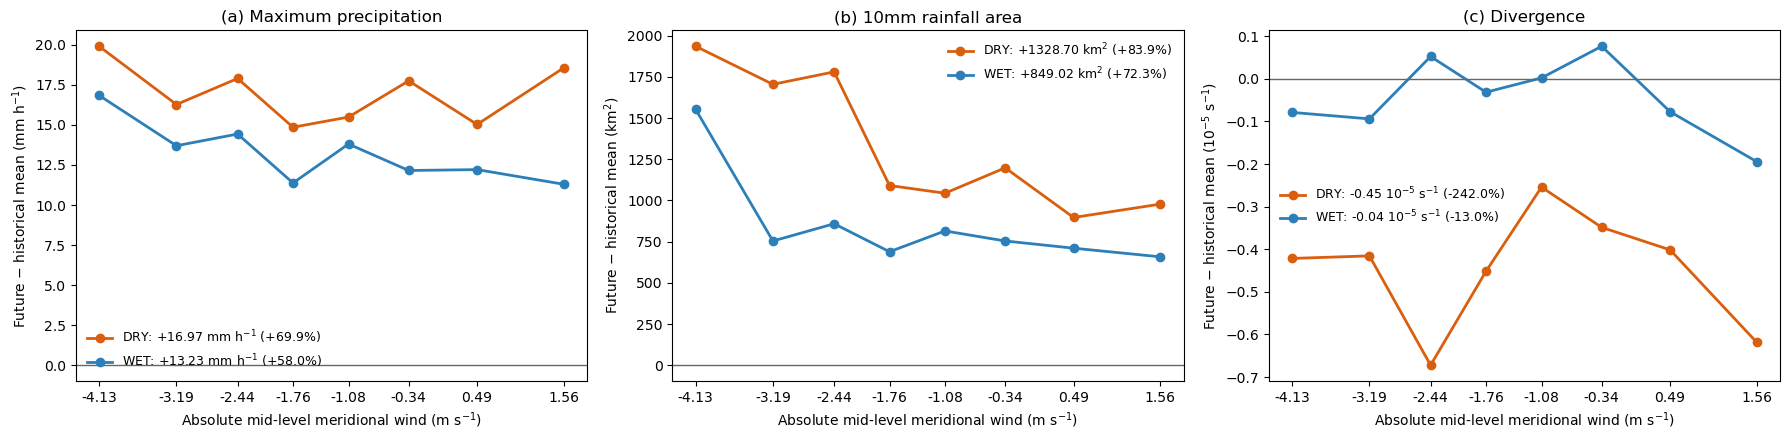

In [98]:
wet_col, dry_col = '#2C7FB8', '#D95F0E'
vvar, smvar = 'v_mid_2deg', 'SM_2deg'
pvar, avar, dvar = 'pmax', 'area_10mm', 'div_2deg'

hist_dry = (lahist[smvar] < histp25) & hist_area
hist_wet = (lahist[smvar] > histp75) & hist_area
fut_dry = (lafut[smvar] < futp25) & fut_area
fut_wet = (lafut[smvar] > futp75) & fut_area

# HIST wind-percentile edges, applied unchanged to both climates; exclude outer tails
v_edges = np.unique(np.nanpercentile(lhist[vvar], np.arange(10, 100, 10)))
v_centres = 0.5 * (v_edges[:-1] + v_edges[1:])

def binned_future_difference(var, hist_mask, fut_mask):
    diffs, hmeans, fmeans, nhist, nfut = [], [], [], [], []

    for i, (vlo, vhi) in enumerate(zip(v_edges[:-1], v_edges[1:])):
        last = i == len(v_edges) - 2
        hbin = hist_mask & (lhist[vvar] >= vlo) & ((lhist[vvar] <= vhi) if last else (lhist[vvar] < vhi))
        fbin = fut_mask & (lfut[vvar] >= vlo) & ((lfut[vvar] <= vhi) if last else (lfut[vvar] < vhi))

        hmean = lahist.loc[hbin, var].mean()
        fmean = lafut.loc[fbin, var].mean()
        hmeans.append(hmean)
        fmeans.append(fmean)
        diffs.append(fmean - hmean)
        nhist.append(hbin.sum())
        nfut.append(fbin.sum())

    return tuple(np.array(x) for x in [diffs, hmeans, fmeans, nhist, nfut])

pmax_dry, pmax_dry_hist, pmax_dry_fut, pmax_dry_nh, pmax_dry_nf = binned_future_difference(pvar, hist_dry, fut_dry)
pmax_wet, pmax_wet_hist, pmax_wet_fut, pmax_wet_nh, pmax_wet_nf = binned_future_difference(pvar, hist_wet, fut_wet)
area_dry, area_dry_hist, area_dry_fut, area_dry_nh, area_dry_nf = binned_future_difference(avar, hist_dry, fut_dry)
area_wet, area_wet_hist, area_wet_fut, area_wet_nh, area_wet_nf = binned_future_difference(avar, hist_wet, fut_wet)
div_dry, div_dry_hist, div_dry_fut, div_dry_nh, div_dry_nf = binned_future_difference(dvar, hist_dry, fut_dry)
div_wet, div_wet_hist, div_wet_fut, div_wet_nh, div_wet_nf = binned_future_difference(dvar, hist_wet, fut_wet)

for i, (vlo, vhi) in enumerate(zip(v_edges[:-1], v_edges[1:])):
    print(f'{vlo:.2f} to {vhi:.2f} m/s | '
          f'DRY: H={pmax_dry_nh[i]}, F={pmax_dry_nf[i]}, ΔPmax={pmax_dry[i]:.2f}, '
          f'ΔArea={area_dry[i] * 4.4**2:.2f}, ΔDiv={div_dry[i]:.2e} | '
          f'WET: H={pmax_wet_nh[i]}, F={pmax_wet_nf[i]}, ΔPmax={pmax_wet[i]:.2f}, '
          f'ΔArea={area_wet[i] * 4.4**2:.2f}, ΔDiv={div_wet[i]:.2e}')

def change_label(label, change, hist, factor, unit):
    valid = np.isfinite(change) & np.isfinite(hist)
    absolute = np.mean(change[valid]) if valid.any() else np.nan
    baseline = np.mean(hist[valid]) if valid.any() else np.nan
    relative = 100 * absolute / baseline if baseline != 0 else np.nan
    return f'{label}: {absolute * factor:+.2f} {unit} ({relative:+.1f}%)'

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True)

# Assumes div_2deg is stored in s^-1; multiply by 1e5 for readable displayed values
panels = [
    (axes[0], pmax_dry, pmax_wet, pmax_dry_hist, pmax_wet_hist, 1,
     r'mm h$^{-1}$', '(a) Maximum precipitation'),
    (axes[1], area_dry, area_wet, area_dry_hist, area_wet_hist, 4.4**2,
     r'km$^2$', '(b) 10mm rainfall area'),
    (axes[2], div_dry, div_wet, div_dry_hist, div_wet_hist, 1e5,
     r'$10^{-5}$ s$^{-1}$', '(c) Divergence')
]

for ax, dry, wet, hdry, hwet, factor, unit, title in panels:
    for label, change, hist, color in [('DRY', dry, hdry, dry_col), ('WET', wet, hwet, wet_col)]:
        legend = change_label(label, change, hist, factor, unit)
        ax.plot(v_centres, change * factor, marker='o', lw=2, color=color, label=legend)

    ax.axhline(0, color='0.4', lw=1)
    ax.set_ylabel(f'Future $-$ historical mean ({unit})')
    ax.set_title(title)
    ax.set_xticks(v_centres)
    ax.set_xticklabels([f'{v:.2f}' for v in v_centres])
    ax.set_xlabel(r'Absolute mid-level meridional wind (m s$^{-1}$)')
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

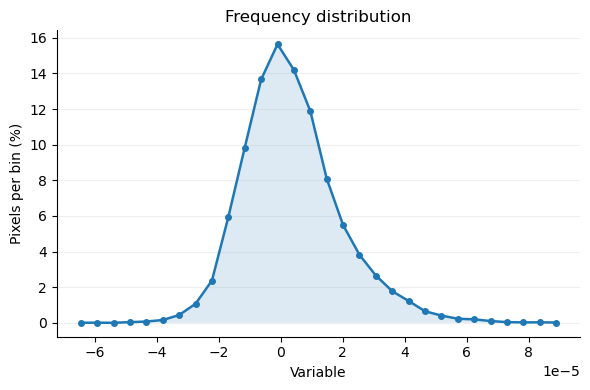

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Your data: works for NumPy arrays or xarray DataArrays
data = lhist['div_2deg'].values.ravel()#*4.4**2
data = data[np.isfinite(data)]

# Define bins
nbins = 30
bin_edges = np.linspace(data.min(), data.max(), nbins + 1)

# Number of pixels in each bin
counts, bin_edges = np.histogram(data, bins=bin_edges)

# Values to plot
x = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # bin centres
y = counts / counts.sum() * 100              # percentage of pixels

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x, y, marker="o", ms=4, lw=1.8)
ax.fill_between(x, 0, y, alpha=0.15)

ax.set(
    xlabel="Variable",
    ylabel="Pixels per bin (%)",
    title="Frequency distribution",
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

In [46]:
import scipy.stats as stats
from scipy.stats import gaussian_kde, linregress
def calc_density(v1,v2):

    xy = np.vstack([v1, v2])

    z = gaussian_kde(xy)(xy)

    return z / (z.max() - z.min())

# cp4s = [lhist[var2], lhist[var]] 
# finites = np.isfinite(cp4s[0])&np.isfinite(cp4s[1])
# cp4s = [(cp4s[0])[finites],(cp4s[1])[finites]]
# r = stats.pearsonr(cp4s[0], cp4s[1])
# density = calc_density(cp4s[0], cp4s[1])
# plt.scatter(cp4s[0], cp4s[1], c=density, cmap='viridis')

# cp4s = [lfut[var2], lfut[var]] 
# finites = np.isfinite(cp4s[0])&np.isfinite(cp4s[1])
# cp4s = [(cp4s[0])[finites],(cp4s[1])[finites]]
# r = stats.pearsonr(cp4s[0], cp4s[1])
# density = calc_density(cp4s[0], cp4s[1])
# plt.scatter(cp4s[0], cp4s[1], c=density, cmap='inferno', alpha=0.3)

In [47]:
from scipy.stats import binned_statistic
def binning(dic, var1, var2, bins):
    func = lambda y: np.nanmean(y)   #  could also be np.percentile(y, 95) etc.
    #func = lambda y: np.nanpercentile(y, 95)  #  could also be np.percentile(y, 95) etc.
    dat, bin_edges, binnumber = binned_statistic(dic[var1], dic[var2], statistic=func, bins=bins)
    tcbins = bin_edges[0:-1] + (bin_edges[1::]-bin_edges[0:-1])/2
  #  ipdb.set_trace()
    pslope, pintercept, pr_value, pp_value, pstd_err = stats.linregress(tcbins[np.isfinite(dat)], dat[np.isfinite(dat)])

    return dat, tcbins, pslope, pintercept, pp_value

SM_2deg dclim: -2.7417392092629473 danom: -1.1673832119152694 dstorm: -3.9091224211782176
sh_2deg dclim: 19.207658465050798 danom: 14.275068341380662 dstorm: 33.48272680643146
lh_2deg dclim: -25.074236846895758 danom: -23.395338527107178 dstorm: -48.469575374002915
sw_net_2deg dclim: -16.10628414507198 danom: -7.203362679855758 dstorm: -23.309646824927768
t_srfc_2deg dclim: 5.721138543644656 danom: 0.28877374264184985 dstorm: 6.0099122862865215
q_srfc_2deg dclim: 0.004634240672248121 danom: 0.00023328657963338315 dstorm: 0.0048675272518815035
tcwv_2deg dclim: 19.141270572546745 danom: 1.6279752185745098 dstorm: 20.76924579112125
thetae_2deg dclim: 21.793091883207012 danom: 1.2763949973330186 dstorm: 23.069486880540012
div_2deg dclim: -1.601937042557704e-06 danom: -2.8464035270767337e-06 dstorm: -4.448340569634438e-06
geoH_srfc_2deg dclim: 12.76223082132151 danom: -0.590458449713018 dstorm: 12.171772371608427
shear_2deg dclim: -0.7798237356730766 danom: -0.07576161782596369 dstorm: -0.8

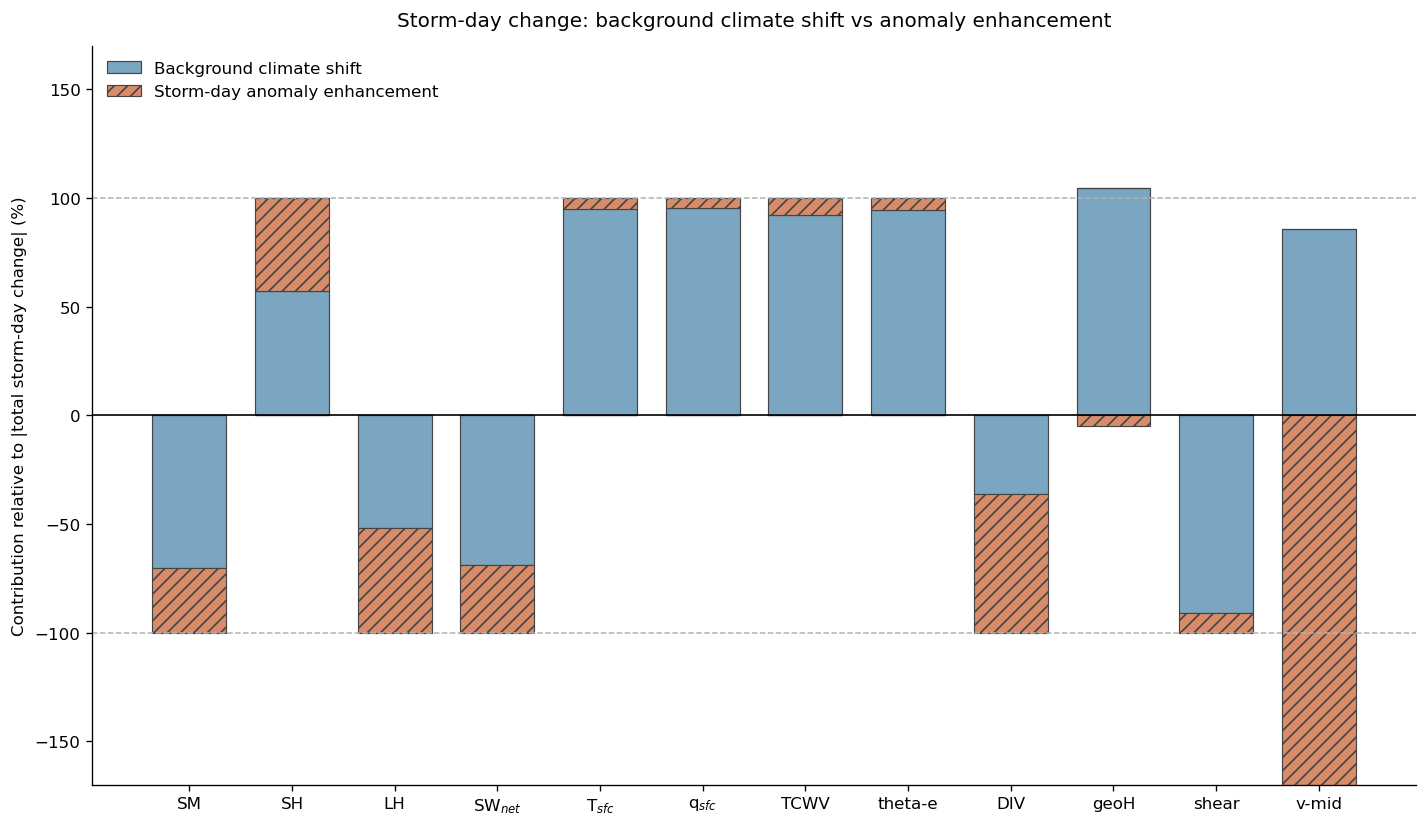

In [137]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

clim = []
anom = []

varts = ['SM_2deg',
         'sh_2deg', 'lh_2deg', 'sw_net_2deg',
         't_srfc_2deg',
         'q_srfc_2deg', 'tcwv_2deg',
         'thetae_2deg', 'div_2deg', 'geoH_srfc_2deg', 'shear_2deg', 'v_mid_2deg']

lab = {'q_srfc_2deg': 'q$_{sfc}$',
       'tcwv_2deg': 'TCWV',
       't_srfc_2deg': 'T$_{sfc}$',
       'lh_2deg': 'LH',
       'sh_2deg': 'SH',
       'thetae_2deg': 'theta-e',
       'div_2deg': 'DIV',
       'sw_net_2deg': 'SW$_{net}$',
       'SM_2deg': 'SM',
       'geoH_srfc_2deg' : 'geoH',
       'shear_2deg' : 'shear',
       'v_mid_2deg' : 'v-mid'}

for v in varts:

    stormhist = np.nanmean(lhist[v].dropna())
    stormfut  = np.nanmean(lfut[v].dropna())

    anohist = np.nanmean(lahist[v].dropna())
    anofut  = np.nanmean(lafut[v].dropna())

    climhist = stormhist - anohist
    climfut  = stormfut - anofut

    dstorm = stormfut - stormhist
    dclim  = climfut - climhist
    danom  = anofut - anohist

    print(v, 'dclim:', dclim, 'danom:', danom, 'dstorm:', dstorm)

    if np.isclose(dstorm, 0):
        clim.append(np.nan)
        anom.append(np.nan)
    else:
        clim.append(dclim / np.abs(dstorm) * 100.)
        anom.append(danom / np.abs(dstorm) * 100.)

x = np.arange(len(varts))
xticks = [lab[v] for v in varts]

clim = np.array(clim)
anom = np.array(anom)

# Positive and negative parts for signed stacking
clim_pos = np.where(clim > 0, clim, 0)
clim_neg = np.where(clim < 0, clim, 0)
anom_pos = np.where(anom > 0, anom, 0)
anom_neg = np.where(anom < 0, anom, 0)

# Colours
c_clim = '#7AA6C2'   # muted blue
c_anom = '#D98C6A'   # muted terracotta
edge   = '#444444'

ax.bar(x, clim_pos, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7,
       label='Background climate shift')
ax.bar(x, clim_neg, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7)

ax.bar(x, anom_pos, width=0.72, bottom=clim_pos, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///', label='Storm-day anomaly enhancement')
ax.bar(x, anom_neg, width=0.72, bottom=clim_neg, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///')

ax.axhline(0, color='k', lw=1.0)
ax.axhline(100, color='0.7', lw=0.9, ls='--')
ax.axhline(-100, color='0.7', lw=0.9, ls='--')

ax.set_xticks(x)
ax.set_xticklabels(xticks)
ax.set_ylabel('Contribution relative to |total storm-day change| (%)')
ax.set_title('Storm-day change: background climate shift vs anomaly enhancement', pad=12)

ax.set_ylim(-170, 170)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

SM_2deg dclim: -2.7417392092629473 danom: -1.1673832119152694 dstorm: -3.9091224211782176
sh_2deg dclim: 19.207658465050798 danom: 14.275068341380662 dstorm: 33.48272680643146
lh_2deg dclim: -25.074236846895758 danom: -23.395338527107178 dstorm: -48.469575374002915
ef_2deg dclim: -5.900537782817686 danom: -4.324730676970991 dstorm: -10.22526845978868
sw_net_2deg dclim: -16.10628414507198 danom: -7.203362679855758 dstorm: -23.309646824927768
t_srfc_2deg dclim: 5.721138543644656 danom: 0.28877374264184985 dstorm: 6.0099122862865215
q_srfc_2deg dclim: 0.004634240672248121 danom: 0.00023328657963338315 dstorm: 0.0048675272518815035
tcwv_2deg dclim: 19.141270572546745 danom: 1.6279752185745098 dstorm: 20.76924579112125
vpd_srfc_2deg dclim: 6.103025691970483 danom: 0.5929040653637622 dstorm: 6.695929757334245


KeyError: 'cape_proxy_2deg'

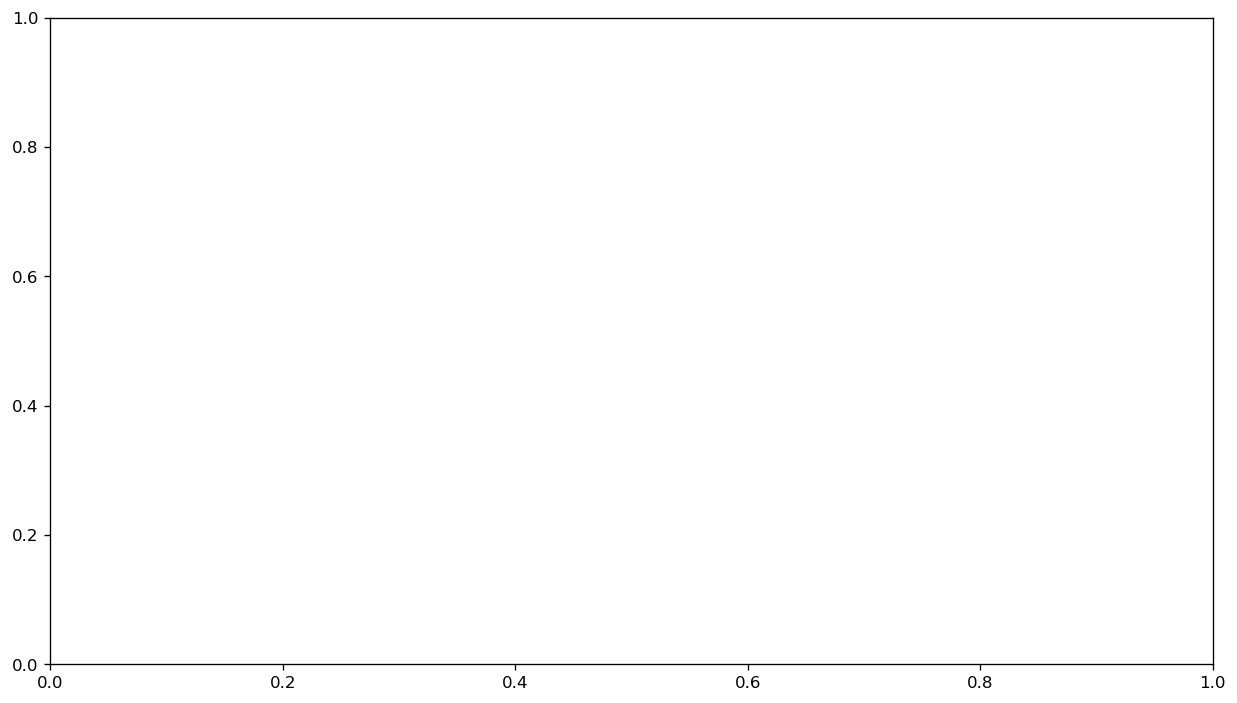

In [168]:
fig, ax = plt.subplots(figsize=(12.5, 7), dpi=120)

clim = []
anom = []

varts = ['SM_2deg',
         'sh_2deg', 'lh_2deg', 'ef_2deg', 'sw_net_2deg',
         't_srfc_2deg',
         'q_srfc_2deg', 'tcwv_2deg', 'vpd_srfc_2deg',
         'cape_proxy_2deg', 'div_2deg']

lab = {'SM_2deg': 'SM',
       'sh_2deg': 'SH',
       'lh_2deg': 'LH',
       'ef_2deg': 'EF',
       'sw_net_2deg': 'SW$_{net}$',
       't_srfc_2deg': 'T$_{sfc}$',
       'q_srfc_2deg': 'q$_{sfc}$',
       'tcwv_2deg': 'TCWV',
       'vpd_srfc_2deg': 'VPD',
       'cape_proxy_2deg': 'CAPE',
       'div_2deg': 'DIV'}

for v in varts:

    stormhist = np.nanmean(lhist[v].dropna())
    stormfut  = np.nanmean(lfut[v].dropna())

    anohist = np.nanmean(lahist[v].dropna())
    anofut  = np.nanmean(lafut[v].dropna())

    climhist = stormhist - anohist
    climfut  = stormfut - anofut

    dstorm = stormfut - stormhist
    dclim  = climfut - climhist
    danom  = anofut - anohist

    print(v, 'dclim:', dclim, 'danom:', danom, 'dstorm:', dstorm)

    if np.isclose(dstorm, 0):
        clim.append(np.nan)
        anom.append(np.nan)
    else:
        clim.append(dclim / np.abs(dstorm) * 100.)
        anom.append(danom / np.abs(dstorm) * 100.)

x = np.arange(len(varts))
xticks = [lab[v] for v in varts]

clim = np.array(clim)
anom = np.array(anom)

# positive and negative pieces for correct signed stacking
clim_pos = np.where(clim > 0, clim, 0)
clim_neg = np.where(clim < 0, clim, 0)

anom_pos = np.where(anom > 0, anom, 0)
anom_neg = np.where(anom < 0, anom, 0)

c_clim = '#7AA6C2'
c_anom = '#D98C6A'
edge = '#444444'

ax.bar(x, clim_pos, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7,
       label='Background climate shift')
ax.bar(x, clim_neg, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7)

ax.bar(x, anom_pos, width=0.72, bottom=clim_pos, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///', label='Storm-day anomaly enhancement')
ax.bar(x, anom_neg, width=0.72, bottom=clim_neg, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///')

ax.axhline(0, color='k', lw=1.0)
ax.axhline(100, color='0.7', lw=0.9, ls='--')
ax.axhline(-100, color='0.7', lw=0.9, ls='--')

ax.set_xticks(x)
ax.set_xticklabels(xticks)
ax.set_ylabel('Contribution relative to |total storm-day change| (%)')
ax.set_title('Storm-day change: background climate shift vs anomaly enhancement', pad=12)

ax.set_ylim(-170, 170)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

sh_2deg dclim: 19.207658465050798 danom: 14.275068341380662 dstorm: 33.48272680643146 stormhist: 155.79563599561956 stormfut: 189.27836280205102 anohist: 14.275328812591349 anofut: 28.55039715397201
lh_2deg dclim: -25.074236846895758 danom: -23.395338527107178 dstorm: -48.469575374002915 stormhist: 261.9045120598344 stormfut: 213.4349366858315 anohist: 12.404407780958007 anofut: -10.99093074614917
sw_net_2deg dclim: -16.10628414507198 danom: -7.203362679855758 dstorm: -23.309646824927768 stormhist: 601.7776773614386 stormfut: 578.4680305365108 anohist: 36.986522150732505 anofut: 29.783159470876747


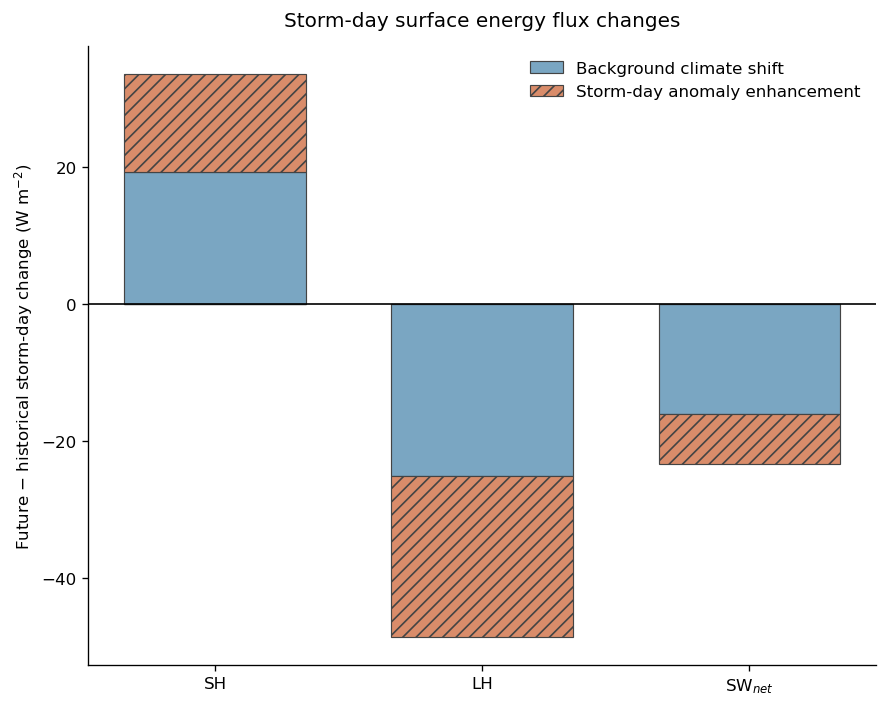

In [169]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 6), dpi=120)

clim = []
anom = []
storm = []

varts = ['sh_2deg', 'lh_2deg', 'sw_net_2deg']

lab = {'sh_2deg': 'SH',
       'lh_2deg': 'LH',
       'sw_net_2deg': 'SW$_{net}$'}

for v in varts:

    stormhist = np.nanmean(lhist[v].dropna())
    stormfut  = np.nanmean(lfut[v].dropna())

    anohist = np.nanmean(lahist[v].dropna())
    anofut  = np.nanmean(lafut[v].dropna())

    climhist = stormhist - anohist
    climfut  = stormfut - anofut

    dstorm = stormfut - stormhist
    dclim  = climfut - climhist
    danom  = anofut - anohist

    print(v, 'dclim:', dclim, 'danom:', danom, 'dstorm:', dstorm,
          'stormhist:', stormhist, 'stormfut:', stormfut,
          'anohist:', anohist, 'anofut:', anofut)

    clim.append(dclim)
    anom.append(danom)
    storm.append(dstorm)

x = np.arange(len(varts))
xticks = [lab[v] for v in varts]

clim = np.array(clim)
anom = np.array(anom)
storm = np.array(storm)

# split positive / negative contributions for correct stacking around zero
clim_pos = np.where(clim > 0, clim, 0)
clim_neg = np.where(clim < 0, clim, 0)

anom_pos = np.where(anom > 0, anom, 0)
anom_neg = np.where(anom < 0, anom, 0)

c_clim = '#7AA6C2'   # muted blue
c_anom = '#D98C6A'   # muted terracotta
edge   = '#444444'

ax.bar(x, clim_pos, width=0.68, color=c_clim, edgecolor=edge, linewidth=0.7,
       label='Background climate shift')
ax.bar(x, clim_neg, width=0.68, color=c_clim, edgecolor=edge, linewidth=0.7)

ax.bar(x, anom_pos, width=0.68, bottom=clim_pos, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///', label='Storm-day anomaly enhancement')
ax.bar(x, anom_neg, width=0.68, bottom=clim_neg, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///')

ax.axhline(0, color='k', lw=1.0)

ax.set_xticks(x)
ax.set_xticklabels(xticks)
ax.set_ylabel('Future − historical storm-day change (W m$^{-2}$)')
ax.set_title('Storm-day surface energy flux changes', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='best')

plt.tight_layout()
plt.show()

dry 6.938834430760201 9.924448573108876
wet 14.675289146038445 17.456569010919058
SM_2deg sign_used: 1 dry_change: 2.985614142348675 wet_change: 2.781279864880613 dry_minus_wet_response: 0.2043342774680621 all_change: 3.9091224211782176 normalised: 5.227113798254375
dry 243.38691147468924 202.0560455191367
wet 120.83495831715541 113.45585209426156
sh_2deg sign_used: 1 dry_change: 41.330865955552554 wet_change: 7.379106222893853 dry_minus_wet_response: 33.9517597326587 all_change: 33.48272680643146 normalised: 101.40082057515446
dry 185.4545822773361 236.20532362680564
wet 272.91471465422046 295.0196178864015
lh_2deg sign_used: 1 dry_change: 50.750741349469536 wet_change: 22.104903232181016 dry_minus_wet_response: 28.64583811728852 all_change: 48.469575374002915 normalised: 59.10065829182602
dry 604.1986882348306 629.9252768515329
wet 547.3804353942908 580.3722964420199
sw_net_2deg sign_used: 1 dry_change: 25.726588616702315 wet_change: 32.99186104772912 dry_minus_wet_response: -7.26527

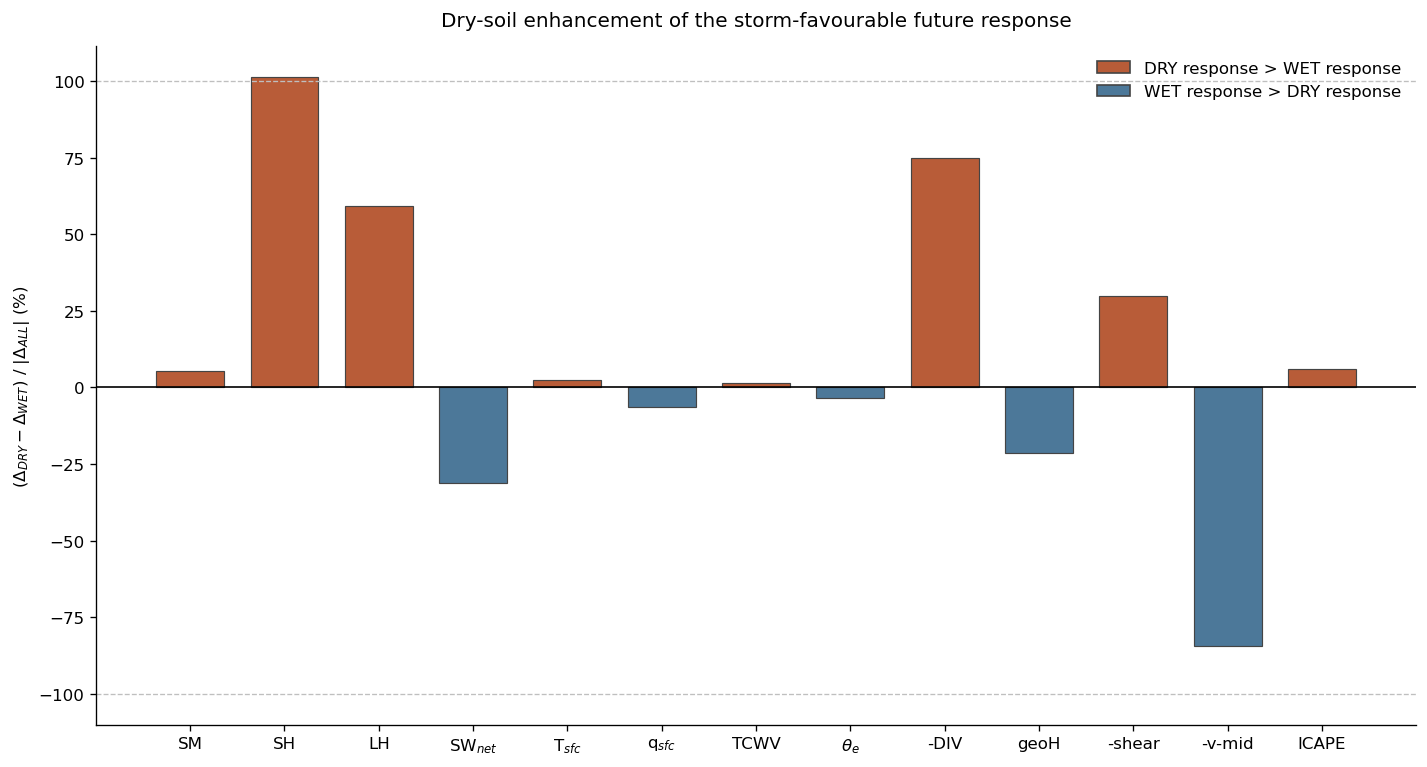

In [171]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 6.5), dpi=120)

# ------------------------------------------------------------------
# Use your existing dry/wet masks here
# DRY = low SM anomaly, WET = high SM anomaly
# ------------------------------------------------------------------
histdry = histposhigh
histwet = histposlow
futdry  = futposhigh
futwet  = futposlow

varts = ['SM_2deg',
         'sh_2deg', 'lh_2deg', 'sw_net_2deg',
         't_srfc_2deg',
         'q_srfc_2deg', 'tcwv_2deg',
         'thetae_2deg', 'div_2deg', 'geoH_srfc_2deg', 'shear_2deg', 'v_mid_2deg', 'ICAPEfull_2deg']

lab = {'q_srfc_2deg': 'q$_{sfc}$',
       'tcwv_2deg': 'TCWV',
       't_srfc_2deg': 'T$_{sfc}$',
       'lh_2deg': 'LH',
       'sh_2deg': 'SH',
       'thetae_2deg': r'$\theta_e$',
       'div_2deg': '-DIV',
       'sw_net_2deg': 'SW$_{net}$',
       'SM_2deg': 'SM',
       'geoH_srfc_2deg': 'geoH',
       'shear_2deg': '-shear',
       'v_mid_2deg': '-v-mid',
      'ICAPEfull_2deg' :'ICAPE'}

# Variables where more negative values are interpreted as more storm-favourable
flip_sign = ['div_2deg', 'shear_2deg', 'v_mid_2deg']
divide = ['ICAPEfull_2deg']

enh_abs = []
enh_norm = []
ddry_all = []
dwet_all = []
dall_all = []

for v in varts:

    sgn = -1 if v in flip_sign else 1
    divi = 10**5 if v in divide else 1

    hist_dry = sgn * np.nanmean(lhist.loc[histdry, v].dropna())
    fut_dry  = sgn * np.nanmean(lfut.loc[futdry, v].dropna()) 

    hist_wet = sgn * np.nanmean(lhist.loc[histwet, v].dropna()) 
    fut_wet  = sgn * np.nanmean(lfut.loc[futwet, v].dropna()) 

    hist_all = sgn * np.nanmean(lhist[v].dropna()) 
    fut_all  = sgn * np.nanmean(lfut[v].dropna())

    ddry = abs(fut_dry - hist_dry)/divi
    dwet = abs(fut_wet - hist_wet) /divi
    dall = abs(fut_all - hist_all) /divi

    print('dry', fut_dry, hist_dry)
    print('wet', fut_wet, hist_wet)

    # dry-soil enhancement of the storm-favourable climate-change response
    enh = (ddry - dwet) 

    ddry_all.append(ddry)
    dwet_all.append(dwet)
    dall_all.append(dall)
    enh_abs.append(enh)

    if np.isclose(dall, 0) or np.isnan(dall):
        enh_norm.append(np.nan)
    else:
        enh_norm.append(enh / np.abs(dall) * 100.)

    print(v,
          'sign_used:', sgn,
          'dry_change:', ddry,
          'wet_change:', dwet,
          'dry_minus_wet_response:', enh,
          'all_change:', dall,
          'normalised:', enh_norm[-1])

x = np.arange(len(varts))
xticks = [lab[v] for v in varts]

enh_norm = np.array(enh_norm)
enh_abs = np.array(enh_abs)
ddry_all = np.array(ddry_all)
dwet_all = np.array(dwet_all)
dall_all = np.array(dall_all)

c_pos = '#B85C38'   # warm terracotta: dry response larger
c_neg = '#4C7899'   # muted blue: wet response larger
edge = '#444444'

cols = np.where(enh_norm >= 0, c_pos, c_neg)

ax.bar(x, enh_norm, width=0.72, color=cols, edgecolor=edge, linewidth=0.7)

ax.axhline(0, color='k', lw=1.0)
ax.axhline(100, color='0.75', lw=0.8, ls='--')
ax.axhline(-100, color='0.75', lw=0.8, ls='--')

ax.set_xticks(x)
ax.set_xticklabels(xticks, rotation=0)
ax.set_ylabel(r'$(\Delta_{DRY} - \Delta_{WET})$ / $|\Delta_{ALL}|$ (%)')
ax.set_title('Dry-soil enhancement of the storm-favourable future response', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_handles = [
    Patch(facecolor=c_pos, edgecolor=edge, label='DRY response > WET response'),
    Patch(facecolor=c_neg, edgecolor=edge, label='WET response > DRY response')
]
ax.legend(handles=legend_handles, frameon=False, loc='best')

plt.tight_layout()
plt.show()

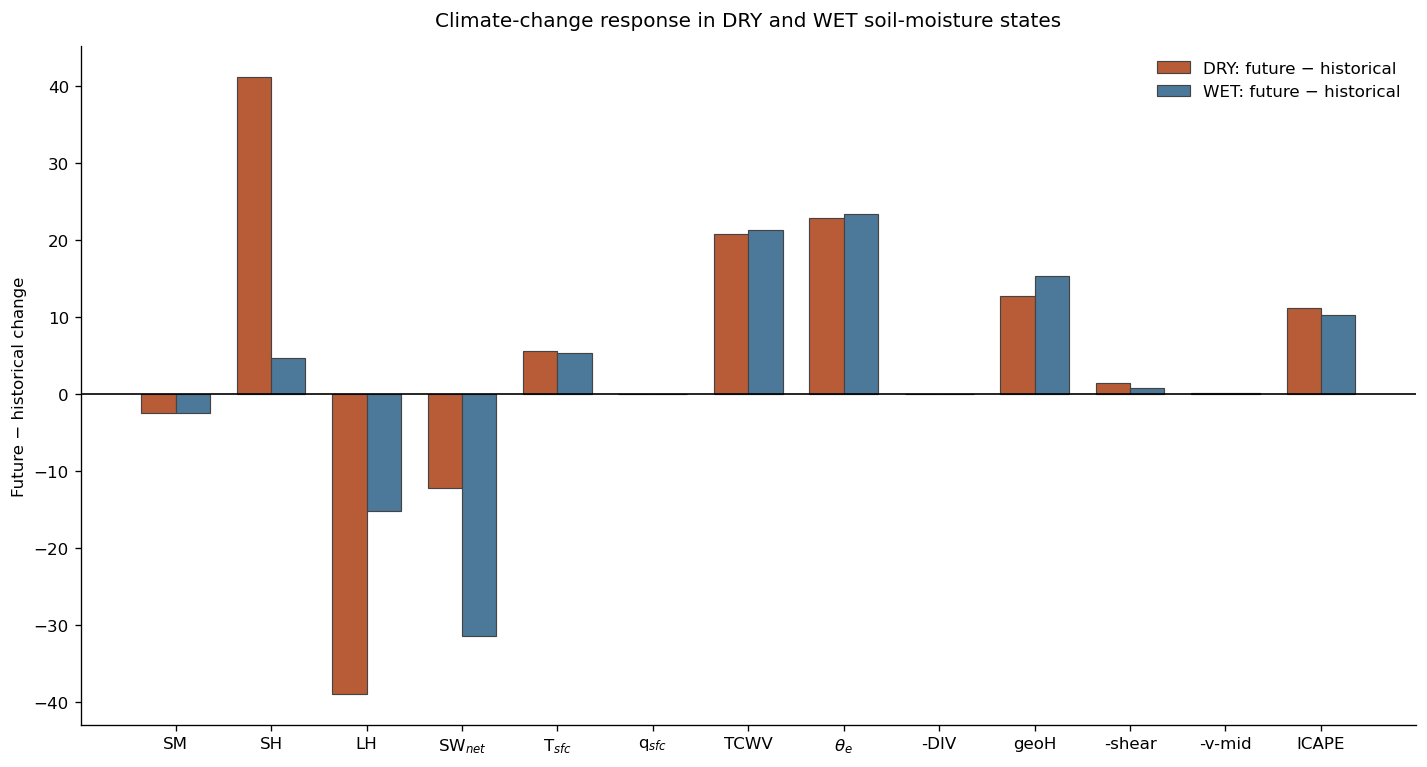

In [165]:
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=120)

x = np.arange(len(varts))
w = 0.36

ax.bar(x - w/2, ddry_all, width=w, color='#B85C38', edgecolor='#444444',
       linewidth=0.7, label='DRY: future − historical')
ax.bar(x + w/2, dwet_all, width=w, color='#4C7899', edgecolor='#444444',
       linewidth=0.7, label='WET: future − historical')

ax.axhline(0, color='k', lw=1.0)

ax.set_xticks(x)
ax.set_xticklabels(xticks)
ax.set_ylabel('Future − historical change')
ax.set_title('Climate-change response in DRY and WET soil-moisture states', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='best')

plt.tight_layout()
plt.show()